![alt text](./Cerny_logo_1.jpg)

# Analysis of Cerny ventilation recordings

## Analysis of mechanically ventilated cases among `AT000001-AT002335`

Explorative data analysis of **799 cases receiving mechanical ventilation** for >=10 minutes.`

This Notebook produces Excel statistics about ventilator parameters in all ventilated cases. It also exports barplots showing statistics on ventilation modes used. It does not produse graphs on individual recordings.

**Author: Dr Gusztav Belteki**

### 1. Import the required libraries and set options

In [3]:
import IPython
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as dates

import os
import sys
import pickle

from pandas import Series, DataFrame
from datetime import datetime, timedelta

%matplotlib inline
matplotlib.style.use('classic')
matplotlib.rcParams['figure.facecolor'] = 'w'

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('future.no_silent_downcasting', True)
pd.set_option('mode.chained_assignment', None) 

In [4]:
print("Python version: {}".format(sys.version))
print("pandas version: {}".format(pd.__version__))
print("matplotlib version: {}".format(matplotlib.__version__))
print("NumPy version: {}".format(np.__version__))
print("IPython version: {}".format(IPython.__version__))

Python version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]
pandas version: 2.3.2
matplotlib version: 3.10.6
NumPy version: 1.26.4
IPython version: 9.5.0


### 2. List and set the working directory and the directory to write out data

In [6]:
# Name of the external hard drive
DRIVE = 'GB_1'

# Path to project folder containing ventilation research results
PATH = os.path.join(os.sep, 'Users', 'guszti', 'Library', 'Mobile Documents', 'com~apple~CloudDocs', 
                            'Documents', 'Research', 'Ventilation')

# Folder to export the result of analysis
DIR_WRITE = os.path.join(PATH, 'ventilation_fabian_new', 'Analyses', 'analysis_ventilated_new')
os.makedirs(DIR_WRITE, exist_ok = True)

# Folder on a USB stick to export data to and to import processed data exported by other Notebooks
DATA_DUMP = os.path.join(os.sep, 'Volumes', DRIVE, 'data_dump', 'fabian_new',)
os.makedirs(DATA_DUMP, exist_ok = True)

DIR_WRITE, DATA_DUMP

('/Users/guszti/Library/Mobile Documents/com~apple~CloudDocs/Documents/Research/Ventilation/ventilation_fabian_new/Analyses/analysis_ventilated_new',
 '/Volumes/GB_1/data_dump/fabian_new')

### 3. Import ventilator and clinical data from pickle archives

In [11]:
# Import ventilator parameters, settings and alarms (AT000001 - AT002100)
with open(os.path.join(DATA_DUMP, 'data_pars_measurements_trimmed_new.pickle'), 'rb') as handle:
    data_pars_measurements_1 = pickle.load(handle)
with open(os.path.join(DATA_DUMP, 'data_pars_settings_trimmed_new.pickle'), 'rb') as handle:
    data_pars_settings_1 = pickle.load(handle)
with open(os.path.join(DATA_DUMP, 'data_pars_alarms_trimmed_new.pickle'), 'rb') as handle:
    data_pars_alarms_1 = pickle.load(handle)

# Import ventilator parameters, settings and alarms (AT002101 - )
with open(os.path.join(DATA_DUMP, 'data_pars_measurements_trimmed_new_2.pickle'), 'rb') as handle:
    data_pars_measurements_2 = pickle.load(handle)
with open(os.path.join(DATA_DUMP, 'data_pars_settings_trimmed_new_2.pickle'), 'rb') as handle:
    data_pars_settings_2 = pickle.load(handle)
with open(os.path.join(DATA_DUMP, 'data_pars_alarms_trimmed_new_2.pickle'), 'rb') as handle:
    data_pars_alarms_2 = pickle.load(handle)

In [12]:
data_pars_measurements = {**data_pars_measurements_1, **data_pars_measurements_2}
data_pars_settings = {**data_pars_settings_1, **data_pars_settings_2}
data_pars_alarms = {**data_pars_alarms_1, **data_pars_alarms_2}
len(data_pars_measurements), len(data_pars_settings), len(data_pars_alarms)

(1848, 1848, 1848)

In [15]:
# Import DataFrame with ventilation modes

# AT000001 - AT002100
with open(os.path.join(DATA_DUMP, 'vent_modes_trimmed_new.pickle'), 'rb') as handle:
    vent_modes_1 = pickle.load(handle)
# AT002101 - 
with open(os.path.join(DATA_DUMP, 'vent_modes_trimmed_new_2.pickle'), 'rb') as handle:
    vent_modes_2 = pickle.load(handle)

vent_modes = pd.concat([vent_modes_1, vent_modes_2], sort = False)
len(vent_modes)

1848

In [17]:
# Import clinical data
with open(os.path.join(DATA_DUMP, 'clin_df_new.pickle'), 'rb') as handle:
    clin_df = pickle.load(handle)
len(clin_df)

1880

### 4. Shift the time stamp of ventilator recordings recorded with incorrect time stamps

Az eltérés valóban az AT000110-estől kezdődik és az AT000216-ig tart. Sajnos volt közben egy téli/nyári váltás is. 
Március 28 után a plusz 9 órával kell korrigálni, előtte 10 órával. 

In [20]:
for case in data_pars_measurements:
    # print(int(case[2:].lstrip('0')))
    if 110 <= int(case[2:].lstrip('0')) < 195:
        data_pars_measurements[case].index = data_pars_measurements[case].index.shift(10, freq='h')
        data_pars_settings[case].index = data_pars_settings[case].index.shift(10, freq='h')
        data_pars_alarms[case].index = data_pars_alarms[case].index.shift(10, freq='h')
        
    elif 195 <= int(case[2:].lstrip('0')) <= 216:
        data_pars_measurements[case].index = data_pars_measurements[case].index.shift(9, freq='h')
        data_pars_settings[case].index = data_pars_settings[case].index.shift(9, freq='h')
        data_pars_alarms[case].index = data_pars_alarms[case].index.shift(9, freq='h')

### 5. Limit data to recordings containing >=10 minutes of mechanical ventilation and keep only parts containing mechanical ventilation

In [23]:
%%time

inv_vent_modes = ['HFO', 'IPPV', 'PSV', 'SIMV', 'SIMVPSV', 'SIPPV',]
data_pars_settings_ventilated = {}
data_pars_measurements_ventilated = {}
data_pars_alarms_ventilated = {}

for recording, dta in data_pars_settings.items():
    data_pars_settings_ventilated[recording] = dta[dta['Ventilator_mode'].isin(inv_vent_modes)]
    data_pars_measurements_ventilated[recording] = data_pars_measurements[recording].reindex(data_pars_settings_ventilated[recording].index)
    data_pars_alarms_ventilated[recording] = data_pars_alarms[recording].reindex(data_pars_settings_ventilated[recording].index)

CPU times: user 810 ms, sys: 320 ms, total: 1.13 s
Wall time: 1.29 s


In [25]:
vent_modes_ventilated = vent_modes[inv_vent_modes + ['VG']]
vent_modes_ventilated['total'] = vent_modes_ventilated[inv_vent_modes].sum(axis=1)
vent_modes_ventilated = vent_modes_ventilated[vent_modes_ventilated['total'] > 0]
vent_modes_ventilated

Ventilator_mode,HFO,IPPV,PSV,SIMV,SIMVPSV,SIPPV,VG,total
AT000005,0.0,0.0,0.0,0.0,0.0,4564.0,4538,4564.0
AT000008,0.0,0.0,0.0,3102.0,0.0,0.0,3102,3102.0
AT000009,0.0,0.0,0.0,650.0,0.0,4488.0,5138,5138.0
AT000017,0.0,0.0,0.0,0.0,0.0,5370.0,5370,5370.0
AT000022,0.0,0.0,0.0,9768.0,0.0,0.0,9594,9768.0
...,...,...,...,...,...,...,...,...
AT002323,0.0,0.0,NaN,0.0,0.0,10.0,0,10.0
AT002325,0.0,0.0,NaN,6152.0,0.0,0.0,38,6152.0
AT002328,0.0,0.0,NaN,6.0,0.0,0.0,0,6.0
AT002332,0.0,0.0,NaN,0.0,0.0,12.0,0,12.0


In [27]:
# Remove recordings when mechanical ventilation was <10 minutes
vent_modes_ventilated = vent_modes_ventilated[vent_modes_ventilated['total'] >= 600]
len(vent_modes_ventilated)

821

In [29]:
data_pars_measurements_ventilated =  {recording: data_pars_measurements_ventilated[recording] for recording in vent_modes_ventilated.index}
data_pars_settings_ventilated =  {recording: data_pars_settings_ventilated[recording] for recording in vent_modes_ventilated.index}
data_pars_alarms_ventilated =  {recording: data_pars_alarms_ventilated[recording] for recording in vent_modes_ventilated.index}
len(data_pars_measurements_ventilated), len(data_pars_settings_ventilated), len(data_pars_alarms_ventilated)

(821, 821, 821)

In [31]:
fhandle = open(os.path.join(DIR_WRITE, 'ventilated_recordings.txt'), 'w')
print(sorted(data_pars_measurements_ventilated.keys()), file=fhandle)
fhandle.close()

In [33]:
clin_df_ventilated = clin_df.reindex(vent_modes_ventilated.index)
len(clin_df_ventilated)

821

##### Export trimmed recordings which contain >=10 minutes of mechanical ventilation

In [36]:
%%time

with open(os.path.join(DATA_DUMP, 'data_pars_measurements_ventilated_new.pickle'), 'wb') as handle:
    pickle.dump(data_pars_measurements_ventilated, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open(os.path.join(DATA_DUMP, 'data_pars_settings_ventilated_new.pickle'), 'wb') as handle:
    pickle.dump(data_pars_settings_ventilated, handle, protocol=pickle.HIGHEST_PROTOCOL)  
with open(os.path.join(DATA_DUMP, 'data_pars_alarms_ventilated_new.pickle'), 'wb') as handle:
    pickle.dump(data_pars_alarms_ventilated, handle, protocol=pickle.HIGHEST_PROTOCOL)

CPU times: user 983 ms, sys: 398 ms, total: 1.38 s
Wall time: 2.5 s


In [38]:
# How many seconds of each ventilation mode in total?
total_duration_ventilated = DataFrame(vent_modes_ventilated.sum(axis = 0), columns = ['duration (seconds)'])
total_duration_ventilated

,duration (seconds)
Ventilator_mode,
HFO,583236.0
IPPV,22186.0
PSV,12804.0
SIMV,1441206.0
SIMVPSV,254646.0
SIPPV,1319300.0
VG,2866572.0
total,3633378.0


In [40]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'ventilation_modes_ventilated_new.xlsx'))
vent_modes_ventilated.to_excel(writer, sheet_name='vent_modes')
total_duration_ventilated.to_excel(writer, sheet_name='total_duration')
writer.close()

In [42]:
with open(os.path.join(DATA_DUMP, 'vent_modes_ventilated_new.pickle'), 'wb') as handle:
    pickle.dump(vent_modes_ventilated, handle, protocol=pickle.HIGHEST_PROTOCOL)

### 6. Statistics on clinical details of ventilated cases

In [45]:
clin_df_ventilated.info()

<class 'pandas.core.frame.DataFrame'>
Index: 821 entries, AT000005 to AT002335
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype          
---  ------                             --------------  -----          
 0   Case ID                            821 non-null    object         
 1   Date of Birth                      821 non-null    datetime64[ns] 
 2   Gestational Age (weeks)            821 non-null    float64        
 3   Birth Weight                       821 non-null    object         
 4   Postnatal Age                      821 non-null    timedelta64[ns]
 5   Corrected gestational Age (weeks)  821 non-null    float64        
 6   Weight                             801 non-null    float64        
 7   ICD                                821 non-null    object         
 8   Pathology_English                  821 non-null    object         
 9   Recording start                    821 non-null    datetime64[ns] 
 10  Recording end      

In [47]:
clin_df_ventilated_stats = round(clin_df_ventilated.describe(percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]), 2)
clin_df_ventilated_stats

,Date of Birth,Gestational Age (weeks),Postnatal Age,Corrected gestational Age (weeks),Weight,Recording start,Recording end,Duration
count,821,821.00,821,821.00,801.00,821,821,821
mean,2023-07-20 20:32:09.719853824,34.74,14 days 13:11:51.946406821,36.81,2629.16,2023-08-04 08:14:17.834348032,2023-08-04 09:44:01.666260736,0 days 01:29:43.831912302
min,2020-10-17 16:29:00,22.00,0 days 00:04:33,22.00,280.00,2020-10-21 10:11:27,2020-10-21 12:24:22,0 days 00:09:58
1%,2020-11-20 14:50:48,23.00,0 days 01:21:07.400000,24.00,500.00,2020-11-20 17:00:44,2020-11-20 18:06:50.800000,0 days 00:14:09.599999999
5%,2021-02-12 09:02:00,25.00,0 days 01:56:28,26.00,730.00,2021-02-17 05:19:48,2021-02-17 06:59:35,0 days 00:31:04
25%,2021-12-09 03:41:00,31.00,0 days 03:26:52,32.30,1730.00,2021-12-19 03:36:27,2021-12-19 05:01:24,0 days 00:50:54
50%,2023-05-16 11:26:00,37.00,0 days 07:34:39,38.00,2800.00,2023-05-22 15:26:52,2023-05-22 16:08:33,0 days 01:23:48
75%,2025-03-12 00:00:00,39.00,7 days 13:11:54,40.00,3490.00,2025-03-13 18:47:52,2025-03-13 19:55:06,0 days 01:55:22
95%,2026-02-10 15:32:00,40.00,83 days 02:32:58,47.20,4250.00,2026-02-20 06:05:43,2026-02-20 07:24:07,0 days 02:56:16
99%,2026-06-07 05:36:00,41.00,155 days 05:14:53.599999928,57.56,4950.00,2026-06-19 01:25:47.600000,2026-06-19 02:52:24.800000,0 days 03:59:47.199999999


In [49]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'clinical_data_ventilated_new.xlsx'))
clin_df_ventilated.to_excel(writer, sheet_name='ventilated_cases')
clin_df_ventilated_stats.to_excel(writer, sheet_name='stats')
writer.close()

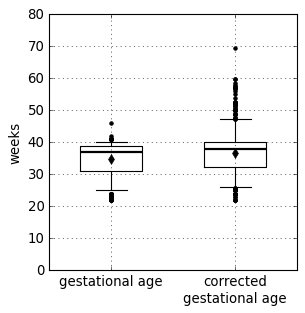

In [51]:
dpi = 300; filetype = 'jpg'
xticklabels = ['gestational age', 'corrected\ngestational age']

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}; boxprops = {'color': 'black', 'linestyle': '-'}
whiskerprops = {'color': 'black', 'linestyle': '-'}; capprops = {'color': 'black', 'linestyle': '-'}; 
flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = (4, 4))
ax.boxplot([clin_df_ventilated['Gestational Age (weeks)'], clin_df_ventilated['Corrected gestational Age (weeks)']], widths=0.5,
    whis = [5, 95], showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, boxprops=boxprops, 
    whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.set_ylim(0, 80)
ax.set_ylabel('weeks', size = 12)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticklabels(xticklabels)
plt.grid(True)
plt.show()

fig.savefig(os.path.join(DIR_WRITE, f'ventilated_gest_age_new.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', 
    pad_inches=0.1,)

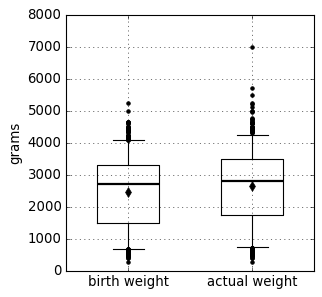

In [53]:
dpi = 300; filetype = 'jpg'
xticklabels = ['birth weight', 'actual weight']

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2};boxprops = {'color': 'black', 'linestyle': '-'}
whiskerprops = {'color': 'black', 'linestyle': '-'}; capprops = {'color': 'black', 'linestyle': '-'}
flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = (4, 4))
ax.boxplot([clin_df_ventilated['Birth Weight'], clin_df_ventilated['Weight'].dropna()], widths=0.5,
    whis = [5, 95], showfliers = True,showmeans = True, meanprops=meanprops, medianprops=medianprops, boxprops=boxprops, 
    whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.set_xticklabels(xticklabels)
ax.set_ylim(0, 8000)
ax.set_ylabel('grams', size = 12)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.grid(True)
plt.show()

fig.savefig(os.path.join(DIR_WRITE, f'ventilated_weight_new.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', 
    pad_inches=0.1,);

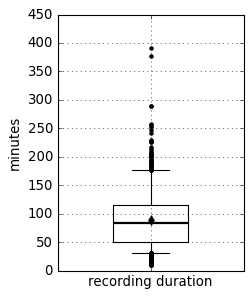

In [55]:
dpi = 300; filetype = 'jpg'
xticklabels = ['recording duration']

# Define styling for each boxplot component
meanprops = {'markerfacecolor': 'black', 'marker' : 'd'}; medianprops = {'color': 'black', 'linewidth': 2}
boxprops = {'color': 'black', 'linestyle': '-'}; whiskerprops = {'color': 'black', 'linestyle': '-'}
capprops = {'color': 'black', 'linestyle': '-'}; flierprops = {'color': 'black', 'marker': '.'}

fig, ax = plt.subplots(figsize = (3, 4))
ax.boxplot(clin_df_ventilated['Duration'] / (60 * 1E+9), widths=0.4,
    whis = [5, 95], showfliers = True,showmeans = True, meanprops=meanprops, medianprops=medianprops, boxprops=boxprops, 
    whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.set_xticklabels(xticklabels)
ax.set_ylabel('minutes', size=12)
ax.set_ylim(0, 450)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.grid(True)
plt.show()

fig.savefig(os.path.join(DIR_WRITE, f'ventilation_duration_new.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', 
    pad_inches=0.1,);

### 7. Descriptive statistics on ventilation modes used

#### A. Which recordings had more than one ventilation mode

In [59]:
ventilated = vent_modes_ventilated.reindex(['SIMV', 'SIMVPSV', 'SIPPV', 'PSV', 'IPPV', 'HFO'], axis = 1)
multiple_mode = [case for case in ventilated.index if (ventilated.loc[case] >0).sum() > 1]
vent_modes_ventilated['multiple_mode'] = np.where(vent_modes_ventilated.index.isin(multiple_mode), 'Yes', 'No')
vent_modes_ventilated.loc[multiple_mode].head()

Ventilator_mode,HFO,IPPV,PSV,SIMV,SIMVPSV,SIPPV,VG,total,multiple_mode
AT000009,0.0,0.0,0.0,650.0,0.0,4488.0,5138,5138.0,Yes
AT000029,0.0,0.0,0.0,512.0,0.0,2454.0,2388,2966.0,Yes
AT000042,0.0,0.0,0.0,226.0,0.0,1694.0,1920,1920.0,Yes
AT000074,0.0,0.0,0.0,6712.0,0.0,22.0,6734,6734.0,Yes
AT000081,872.0,0.0,0.0,0.0,0.0,2548.0,3368,3420.0,Yes


#### B. Consider all modes used during recordings

In [62]:
print('SIMV:', sum(vent_modes_ventilated['SIMV'] > 0))
print('SIPPV:', sum(vent_modes_ventilated['SIPPV'] > 0))
print('SIMVPSV:', sum(vent_modes_ventilated['SIMVPSV'] > 0))
print('PSV:', sum(vent_modes_ventilated['PSV'] > 0))
print('IPPV:', sum(vent_modes_ventilated['IPPV'] > 0))
print('VG:', sum(vent_modes_ventilated['VG'] > 0))
print('HFOV:', sum(vent_modes_ventilated['HFO'] > 0))
print('total', len(vent_modes_ventilated))

SIMV: 385
SIPPV: 409
SIMVPSV: 85
PSV: 7
IPPV: 15
VG: 716
HFOV: 154
total 821


In [64]:
def autolabel(rects):
    """
    Attach a text label above each bar displaying its height
    """
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., 1.05*height, '%d' % int(height), ha='center', va='bottom', size = 14)

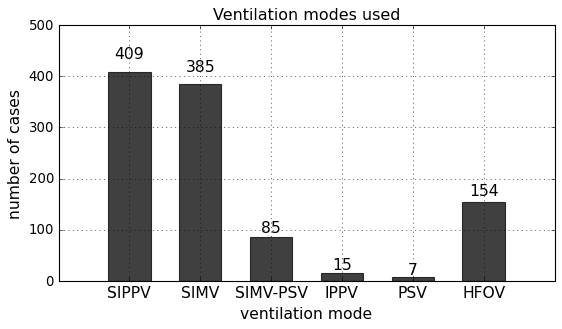

In [66]:
dpi = 300; filetype = 'jpg'
labels = ['SIPPV', 'SIMV', 'SIMV-PSV', 'IPPV', 'PSV', 'HFOV']
xticks = np.arange(len(labels))
width = 0.6

fig, ax = plt.subplots(figsize = [8,4])
rects = ax.bar(xticks, [sum(vent_modes_ventilated['SIPPV'] > 0), sum(vent_modes_ventilated['SIMV'] > 0), 
                        sum(vent_modes_ventilated['SIMVPSV'] > 0), sum(vent_modes_ventilated['IPPV'] > 0), 
                        sum(vent_modes_ventilated['PSV'] > 0), sum(vent_modes_ventilated['HFO'] > 0),], 
                width=width, color='black', alpha  = 0.75, align = 'center')

ax.set_xlabel('ventilation mode', size = 14)
ax.set_xticks(xticks)
ax.set_xticklabels(labels, size = 14, rotation = 0)
ax.set_ylabel('number of cases', size = 14)
ax.set_title('Ventilation modes used')
ax.set_ylim(0, 500)
ax.grid(True)
autolabel(rects)
plt.show()

fig.savefig(os.path.join(DIR_WRITE, f'vent_modes_ventilated_new.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', 
    pad_inches=0.1,);

#### C. Consider only the predominant ventilation mode

In [69]:
vent_modes_ventilated['dominant_mode'] = vent_modes_ventilated[['SIMV', 'SIMVPSV', 'SIPPV', 'PSV', 'HFO', 'IPPV']].idxmax(axis = 1)
vent_modes_ventilated.head()

Ventilator_mode,HFO,IPPV,PSV,SIMV,SIMVPSV,SIPPV,VG,total,multiple_mode,dominant_mode
AT000005,0.0,0.0,0.0,0.0,0.0,4564.0,4538,4564.0,No,SIPPV
AT000008,0.0,0.0,0.0,3102.0,0.0,0.0,3102,3102.0,No,SIMV
AT000009,0.0,0.0,0.0,650.0,0.0,4488.0,5138,5138.0,Yes,SIPPV
AT000017,0.0,0.0,0.0,0.0,0.0,5370.0,5370,5370.0,No,SIPPV
AT000022,0.0,0.0,0.0,9768.0,0.0,0.0,9594,9768.0,No,SIMV


In [71]:
vent_modes_ventilated['dominant_mode'].value_counts()

dominant_mode
SIPPV      309
SIMV       307
HFO        126
SIMVPSV     68
IPPV         8
PSV          3
Name: count, dtype: int64

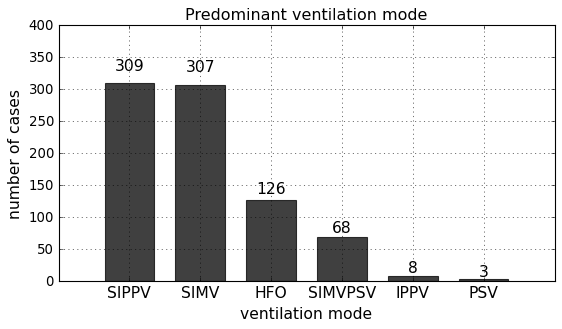

In [73]:
dpi = 300; filetype = 'jpg'
xticklabels = vent_modes_ventilated['dominant_mode'].value_counts().index
xticks = np.arange(len(vent_modes_ventilated['dominant_mode'].value_counts()))

fig, ax = plt.subplots(figsize = [8,4])
rects = ax.bar(xticks, vent_modes_ventilated['dominant_mode'].value_counts(), color='black',width = 0.7, alpha  = 0.75, )
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, size = 14, rotation = 0)
ax.set_xlabel('ventilation mode', size = 14)
ax.set_ylabel('number of cases', size = 14)
ax.set_title('Predominant ventilation mode')
ax.set_ylim(0, 400)
ax.grid(True)
autolabel(rects)
plt.show()

fig.savefig(os.path.join(DIR_WRITE, f'vent_modes_ventilated_dominant_mode_new.{filetype}'),
    dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

#### D. Consider only the recordings with a single ventilator mode

In [76]:
sum(vent_modes_ventilated['multiple_mode'] == 'No')

616

In [78]:
only_mode = vent_modes_ventilated[vent_modes_ventilated['multiple_mode'] == 'No']['dominant_mode'].value_counts()
only_mode

dominant_mode
SIPPV      242
SIMV       231
HFO         86
SIMVPSV     49
IPPV         6
PSV          2
Name: count, dtype: int64

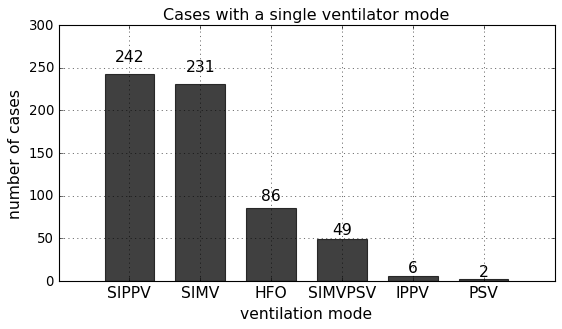

In [80]:
dpi = 300; filetype = 'jpg'
xticklabels = only_mode.index
xticks = np.arange(len(only_mode))

fig, ax = plt.subplots(figsize = [8,4])
rects = ax.bar(xticks, only_mode, color='black', width = 0.7, alpha  = 0.75)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, size = 14, rotation = 0)
ax.set_xlabel('ventilation mode', size = 14)
ax.set_ylabel('number of cases', size = 14)
ax.set_title('Cases with a single ventilator mode')
ax.set_ylim(0, 300)
ax.grid(True)
autolabel(rects)
plt.show()

fig.savefig(os.path.join(DIR_WRITE, f'vent_modes_ventilated_only_mode_new.{filetype}'), dpi = dpi, format = filetype, 
    bbox_inches='tight', pad_inches=0.1,);

#### E. How many recordings had VG ventilation and for how long

In [83]:
# No VG ventilation
sum(vent_modes_ventilated['VG'] == 0)

105

In [85]:
# has some VG ventilationa
sum(vent_modes_ventilated['VG'] > 0)

716

In [87]:
# VG was on throughout the whole recording
only_VG = vent_modes_ventilated['VG'] == vent_modes_ventilated['total']
sum(only_VG)

398

In [89]:
vent_modes_ventilated[only_VG]['dominant_mode'].value_counts()

dominant_mode
SIMV       175
SIPPV      168
SIMVPSV     31
HFO         21
IPPV         2
PSV          1
Name: count, dtype: int64

In [91]:
# Save extended file about ventilation modes to pickle archive
with open(os.path.join(DATA_DUMP, 'vent_modes_ventilated_new_analysed.pickle'), 'wb') as handle:
    pickle.dump(vent_modes_ventilated, handle, protocol=pickle.HIGHEST_PROTOCOL)

### 8. Cleanup ventilator parameters

In [94]:
for case in data_pars_measurements_ventilated:
    # Remove empty columns of parameters which are not mechanical ventilation
    data_pars_measurements_ventilated[case].dropna(how = 'all', axis = 1, inplace = True)
    # Make sure the type of all remaining parameter is float
    data_pars_measurements_ventilated[case] = data_pars_measurements_ventilated[case].astype('float')

In [95]:
# Replace 255 with np.nan for the 'RR_CO2' parameter values (this should have been done during initial processing
# and eventually should be moved there)
for case in data_pars_measurements_ventilated:
    if 'RR_CO2' in data_pars_measurements_ventilated[case].columns:
        data_pars_measurements_ventilated[case]['RR_CO2'] = data_pars_measurements_ventilated[case]['RR_CO2'].replace(255, np.nan)

### 9. Descriptive statistics on measured ventilator parameters

#### A. Statistics on individual cases

In [100]:
%%time

stats_pars_measurements_ventilated = {} 
percentiles = [0.05, 0.25, 0.5, 0.75, 0.95]

for case in data_pars_measurements_ventilated:
    stats_pars_measurements_ventilated[case] = round(data_pars_measurements_ventilated[case].describe(percentiles=percentiles), 2)
    stats_pars_measurements_ventilated[case].index = ['data_points', 'mean', 'SD', 'min', '5pc', '25pc', 'median', '75pc', '95pc', 'max']

# Create table with statistics for all cases
stats_pars_measurements_ventilated_all_cases = pd.concat(stats_pars_measurements_ventilated, axis = 1).T

# Remove measured parameters not present in case of mechanical ventilation
stats_pars_measurements_ventilated_all_cases = stats_pars_measurements_ventilated_all_cases.dropna(how = 'all', 
    subset = ['mean', 'SD', 'min', '5pc', '25pc', 'median', '75pc', '95pc', 'max'], axis = 0,)

stats_pars_measurements_ventilated_all_cases.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 17950 entries, ('AT000005', 'PIP') to ('AT002335', 'DCO2_kg2')
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   data_points  17950 non-null  float64
 1   mean         17950 non-null  float64
 2   SD           17899 non-null  float64
 3   min          17950 non-null  float64
 4   5pc          17950 non-null  float64
 5   25pc         17950 non-null  float64
 6   median       17950 non-null  float64
 7   75pc         17950 non-null  float64
 8   95pc         17950 non-null  float64
 9   max          17950 non-null  float64
dtypes: float64(10)
memory usage: 1.5+ MB
CPU times: user 6.31 s, sys: 69.9 ms, total: 6.38 s
Wall time: 6.38 s


In [101]:
stats_pars_measurements_ventilated_all_cases.head()

data_points   mean    SD  min    5pc  25pc  median   75pc  \
AT000005 PIP         2282.0  27.24  4.85  0.7  16.00  26.7    29.5  29.80   
         MAP         2282.0  13.24  1.70  0.0  10.31  12.6    13.6  14.30   
         PEEP        2282.0   6.76  0.40  0.2   6.50   6.7     6.7   6.80   
         Cdyn        2282.0   0.24  0.24  0.0   0.10   0.1     0.2   0.20   
         C20_C       2282.0   9.32  8.41  0.2   1.10   3.5     5.9  13.28   

                95pc   max  
AT000005 PIP    30.7  34.5  
         MAP    15.1  16.4  
         PEEP    7.2   9.3  
         Cdyn    0.7   2.1  
         C20_C  27.0  46.3

In [102]:
stats_pars_measurements_ventilated_all_cases.loc['AT000030']

,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max
PIP,518.0,17.80,10.24,1.70,7.00,7.70,14.50,28.90,32.60,39.90
MAP,518.0,5.87,1.46,0.00,4.39,5.10,5.70,7.10,7.61,8.50
PEEP,518.0,4.67,0.52,0.60,4.00,4.60,4.80,4.90,5.00,5.80
Cdyn,518.0,3.42,2.85,0.30,0.30,0.90,3.00,6.00,8.60,10.10
C20_C,518.0,2.69,2.05,0.10,0.20,0.40,2.80,3.90,6.40,9.70
R,518.0,192.33,126.88,49.60,56.17,72.15,166.00,286.10,424.98,501.30
MV,518.0,1.17,0.73,0.00,0.24,0.76,1.03,1.37,2.87,4.21
MVresp,518.0,57.09,22.69,0.00,14.00,43.00,58.00,72.00,96.00,100.00
VTemand,518.0,26.80,10.17,0.00,14.40,17.90,25.10,33.78,43.83,58.70
VTemand_resp,518.0,24.13,11.63,0.00,9.60,17.80,20.50,30.98,45.63,63.10


In [103]:
stats_pars_measurements_ventilated_all_cases.loc['AT001650']

,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max
PIP,2203.0,36.35,2.31,1.50,34.10,36.30,36.60,37.00,37.60,45.50
MAP,2203.0,15.39,2.15,0.00,13.80,15.60,15.70,15.70,16.60,19.90
MV,2203.0,3.13,0.43,0.50,2.49,2.95,3.18,3.45,3.56,5.68
Leak,2203.0,0.18,3.12,0.00,0.00,0.00,0.00,0.00,0.00,64.00
VTimand,2203.0,6.62,1.84,0.00,5.40,6.10,6.60,7.20,7.40,33.70
deltaP,2203.0,36.90,2.82,2.10,36.40,37.00,37.30,37.50,37.80,42.70
VThf_emand,2203.0,6.52,0.93,0.00,5.30,6.10,6.60,7.20,7.40,12.10
DCO2,2203.0,345.01,88.03,0.00,208.00,297.00,348.00,414.00,438.00,1171.00
HFOV_freq,2203.0,7.97,0.41,2.00,8.00,8.00,8.00,8.00,8.00,10.00
FiO2,2203.0,97.78,8.48,21.00,97.40,97.70,98.70,100.00,100.00,100.00


In [118]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_measurements_ventilated_new_cases.xlsx'))
for case in stats_pars_measurements_ventilated:
    stats_pars_measurements_ventilated_all_cases.loc[case].to_excel(writer, sheet_name=case)
writer.close()

In [119]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_measurements_ventilated_new_cases_all.xlsx'))
stats_pars_measurements_ventilated_all_cases.to_excel(writer, sheet_name='cases')
writer.close()

#### B. Statistics on individual parameters

In [123]:
parameters_all = stats_pars_measurements_ventilated_all_cases.index.levels[1]
parameters_all

Index(['C20_C', 'Cdyn', 'Cdyn_kg', 'DCO2', 'DCO2_kg2', 'FiO2', 'Flow_demand',
       'Flow_exp', 'Flow_insp', 'HFOV_freq', 'Leak', 'MAP', 'MV', 'MV_kg',
       'MVresp', 'PEEP', 'PIP', 'R', 'RR', 'RR_CO2', 'TC', 'Ti_PSV', 'Trigger',
       'VTemand', 'VTemand_kg', 'VTemand_resp', 'VTemand_resp_kg',
       'VTespon_pat', 'VTespon_pat_kg', 'VThf_emand', 'VThf_emand_kg',
       'VTimand', 'VTimand_kg', 'deltaP', 'etCO2'],
      dtype='object')

In [125]:
# SIPPV ventilation
data_pars_measurements_ventilated['AT001880'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4561 entries, 2025-07-19 18:16:30 to 2025-07-19 20:48:30
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PIP         4561 non-null   float64
 1   MAP         4561 non-null   float64
 2   PEEP        4561 non-null   float64
 3   Cdyn        4561 non-null   float64
 4   C20_C       4561 non-null   float64
 5   R           4561 non-null   float64
 6   MV          4561 non-null   float64
 7   VTemand     4561 non-null   float64
 8   Leak        4561 non-null   float64
 9   RR          4561 non-null   float64
 10  Trigger     4561 non-null   float64
 11  VTimand     4561 non-null   float64
 12  FiO2        4561 non-null   float64
 13  TC          4561 non-null   float64
 14  MV_kg       4561 non-null   float64
 15  VTimand_kg  4561 non-null   float64
 16  VTemand_kg  4561 non-null   float64
 17  Cdyn_kg     4561 non-null   float64
dtypes: float64(18)
memory usage: 677

In [127]:
# SIMV ventilation
data_pars_measurements_ventilated['AT001874'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2745 entries, 2025-07-16 13:38:16 to 2025-07-16 15:09:44
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PIP              2745 non-null   float64
 1   MAP              2745 non-null   float64
 2   PEEP             2745 non-null   float64
 3   Cdyn             2745 non-null   float64
 4   C20_C            2745 non-null   float64
 5   R                2745 non-null   float64
 6   MV               2745 non-null   float64
 7   MVresp           2745 non-null   float64
 8   VTemand          2745 non-null   float64
 9   VTemand_resp     2745 non-null   float64
 10  VTespon_pat      2745 non-null   float64
 11  Leak             2745 non-null   float64
 12  RR               2745 non-null   float64
 13  Trigger          2745 non-null   float64
 14  VTimand          2745 non-null   float64
 15  FiO2             2745 non-null   float64
 16  TC               2745 no

In [129]:
# SIMVPSV ventilation
data_pars_measurements_ventilated['AT001769'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4930 entries, 2025-05-01 22:53:15 to 2025-05-02 01:38:45
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PIP              4930 non-null   float64
 1   MAP              4930 non-null   float64
 2   PEEP             4930 non-null   float64
 3   Ti_PSV           4790 non-null   float64
 4   Cdyn             4930 non-null   float64
 5   C20_C            4930 non-null   float64
 6   R                4930 non-null   float64
 7   MV               4930 non-null   float64
 8   MVresp           4928 non-null   float64
 9   VTemand          4930 non-null   float64
 10  VTemand_resp     4930 non-null   float64
 11  VTespon_pat      4930 non-null   float64
 12  Leak             4930 non-null   float64
 13  RR               4930 non-null   float64
 14  Trigger          4928 non-null   float64
 15  VTimand          4930 non-null   float64
 16  FiO2             4930 no

In [131]:
# PSV ventilation
data_pars_measurements_ventilated['AT001006'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2176 entries, 2023-03-02 10:12:00 to 2023-03-02 11:24:30
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PIP         2176 non-null   float64
 1   MAP         2176 non-null   float64
 2   PEEP        2176 non-null   float64
 3   Ti_PSV      2176 non-null   float64
 4   Cdyn        2176 non-null   float64
 5   C20_C       2176 non-null   float64
 6   R           2176 non-null   float64
 7   MV          2176 non-null   float64
 8   VTemand     2176 non-null   float64
 9   Leak        2176 non-null   float64
 10  RR          2176 non-null   float64
 11  Trigger     2176 non-null   float64
 12  VTimand     2176 non-null   float64
 13  FiO2        2176 non-null   float64
 14  TC          2176 non-null   float64
 15  RR_CO2      16 non-null     float64
 16  MV_kg       2176 non-null   float64
 17  VTimand_kg  2176 non-null   float64
 18  VTemand_kg  2176 non-null   floa

In [133]:
# HFO ventilation
data_pars_measurements_ventilated['AT001891'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1808 entries, 2025-07-25 15:11:01 to 2025-07-25 16:11:15
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PIP            1808 non-null   float64
 1   MAP            1808 non-null   float64
 2   MV             1808 non-null   float64
 3   Leak           1808 non-null   float64
 4   VTimand        1808 non-null   float64
 5   deltaP         1808 non-null   float64
 6   VThf_emand     1808 non-null   float64
 7   DCO2           1808 non-null   float64
 8   HFOV_freq      1808 non-null   float64
 9   FiO2           1808 non-null   float64
 10  MV_kg          1808 non-null   float64
 11  VTimand_kg     1808 non-null   float64
 12  VThf_emand_kg  1808 non-null   float64
 13  DCO2_kg2       1808 non-null   float64
dtypes: float64(14)
memory usage: 211.9 KB


In [135]:
parameters = ['C20_C', 'Cdyn_kg', 'DCO2_kg2', 'FiO2', 'HFOV_freq', 'Leak', 'MAP', 'MV_kg', 'MVresp', 'PEEP', 'PIP', 'R', 'RR', 'RR_CO2',
              'TC', 'Ti_PSV', 'Trigger', 'VTemand_kg',  'VTemand_resp_kg', 'VTespon_pat_kg', 'VThf_emand_kg', 'VTimand_kg', 'deltaP', 
              'etCO2']

In [137]:
# Individual parameters
stats_pars_measurements_ventilated_parameters = {}

for parameter in parameters:
    stats_pars_measurements_ventilated_parameters[parameter] = stats_pars_measurements_ventilated_all_cases.swaplevel(0,1).loc[parameter]

In [139]:
stats_pars_measurements_ventilated_parameters['VTemand_kg'].head()

,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max
AT000005,2282.0,4.38,1.21,0.00,3.13,3.83,4.26,4.78,6.09,16.52
AT000008,1551.0,5.19,0.24,2.54,4.78,5.18,5.22,5.26,5.39,5.83
AT000009,2569.0,4.18,0.91,0.00,2.75,3.38,4.38,4.88,5.25,9.00
AT000017,2685.0,6.15,0.75,3.27,4.62,5.96,6.35,6.54,6.73,10.96
AT000022,4884.0,6.37,1.37,0.00,4.47,5.57,6.23,7.15,8.68,11.97


In [141]:
# Unstack table to create table with different configuration
stats_pars_measurements_ventilated_all_parameters = stats_pars_measurements_ventilated_all_cases.unstack()
stats_pars_measurements_ventilated_all_parameters = stats_pars_measurements_ventilated_all_parameters.swaplevel(axis=1)
stats_pars_measurements_ventilated_all_parameters = stats_pars_measurements_ventilated_all_parameters[parameters]
stats_pars_measurements_ventilated_all_parameters = stats_pars_measurements_ventilated_all_parameters.swaplevel(axis=1)
stats_pars_measurements_ventilated_all_parameters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 821 entries, AT000005 to AT002335
Columns: 240 entries, ('data_points', 'C20_C') to ('max', 'etCO2')
dtypes: float64(240)
memory usage: 1.5+ MB


In [143]:
stats_pars_measurements_ventilated_all_parameters.head()

,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max,...,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max
,C20_C,C20_C,C20_C,C20_C,C20_C,C20_C,C20_C,C20_C,C20_C,C20_C,Cdyn_kg,Cdyn_kg,Cdyn_kg,Cdyn_kg,Cdyn_kg,Cdyn_kg,Cdyn_kg,Cdyn_kg,Cdyn_kg,Cdyn_kg,DCO2_kg2,DCO2_kg2,DCO2_kg2,DCO2_kg2,DCO2_kg2,DCO2_kg2,DCO2_kg2,DCO2_kg2,DCO2_kg2,DCO2_kg2,FiO2,FiO2,FiO2,FiO2,FiO2,FiO2,FiO2,FiO2,FiO2,FiO2,HFOV_freq,HFOV_freq,HFOV_freq,HFOV_freq,HFOV_freq,HFOV_freq,HFOV_freq,HFOV_freq,HFOV_freq,HFOV_freq,...,VTespon_pat_kg,VTespon_pat_kg,VTespon_pat_kg,VTespon_pat_kg,VTespon_pat_kg,VTespon_pat_kg,VTespon_pat_kg,VTespon_pat_kg,VTespon_pat_kg,VTespon_pat_kg,VThf_emand_kg,VThf_emand_kg,VThf_emand_kg,VThf_emand_kg,VThf_emand_kg,VThf_emand_kg,VThf_emand_kg,VThf_emand_kg,VThf_emand_kg,VThf_emand_kg,VTimand_kg,VTimand_kg,VTimand_kg,VTimand_kg,VTimand_kg,VTimand_kg,VTimand_kg,VTimand_kg,VTimand_kg,VTimand_kg,deltaP,deltaP,deltaP,deltaP,deltaP,deltaP,deltaP,deltaP,deltaP,deltaP,etCO2,etCO2,etCO2,etCO2,etCO2,etCO2,etCO2,etCO2,etCO2,etCO2
AT000005,2282.0,9.32,8.41,0.2,1.1,3.5,5.9,13.28,27.0,46.3,2282.0,0.21,0.20,0.00,0.09,0.09,0.17,0.17,0.61,1.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2282.0,21.07,0.10,20.8,20.9,21.0,21.1,21.1,21.2,21.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2282.0,6.68,1.30,0.0,5.04,6.09,6.78,7.22,8.35,18.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2277.0,25.61,3.99,6.0,19.0,23.0,26.0,29.0,32.0,36.0
AT000008,1551.0,3.85,1.23,1.5,2.7,3.0,3.4,4.30,6.5,8.5,1551.0,0.45,0.04,0.26,0.39,0.44,0.44,0.44,0.53,0.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1551.0,57.58,5.64,34.4,49.6,59.4,59.9,60.2,60.5,60.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1551.0,0.00,0.03,0.0,0.0,0.0,0.00,0.00,0.00,0.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1551.0,5.39,0.17,0.0,5.22,5.35,5.39,5.44,5.53,5.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1543.0,30.81,1.30,0.0,30.0,30.0,31.0,32.0,32.0,35.0
AT000009,2569.0,3.87,3.43,0.0,0.3,1.5,2.6,5.60,10.8,24.0,2569.0,0.13,0.08,0.00,0.00,0.12,0.12,0.12,0.25,0.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2569.0,24.27,1.60,20.5,20.6,24.6,24.8,25.2,25.3,25.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,324.0,0.32,0.27,0.0,0.0,0.0,0.37,0.50,0.62,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2569.0,5.70,2.75,0.0,4.12,4.75,5.75,6.37,6.88,55.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2319.0,38.87,4.78,0.0,33.0,36.0,38.0,42.0,46.0,50.0
AT000017,2685.0,8.26,5.66,0.0,0.4,4.6,6.8,11.40,19.6,34.0,2685.0,0.17,0.07,0.00,0.00,0.19,0.19,0.19,0.19,0.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2685.0,25.70,11.32,20.3,20.4,21.0,24.9,25.8,30.4,97.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2685.0,7.23,0.91,0.0,5.77,6.92,7.50,7.69,8.46,10.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1550.0,18.01,1.20,0.0,17.0,17.0,18.0,19.0,20.0,23.0
AT000022,4884.0,0.63,0.83,0.0,0.1,0.2,0.4,0.80,2.0,11.3,4884.0,2.81,1.23,0.00,0.96,2.02,2.76,3.46,4.91,13.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4884.0,66.21,36.30,20.5,20.5,25.4,97.3,98.2,99.4,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4884.0,3.94,2.80,0.0,0.0,0.0,4.96,6.01,7.46,10.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4884.0,6.93,1.47,0.0,5.22,6.10,6.80,7.68,9.47,20.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4874.0,24.35,4.65,0.0,17.0,23.0,26.0,27.0,29.0,34.0


In [145]:
stats_pars_measurements_ventilated_all_parameters['mean'].head()

,C20_C,Cdyn_kg,DCO2_kg2,FiO2,HFOV_freq,Leak,MAP,MV_kg,MVresp,PEEP,PIP,R,RR,RR_CO2,TC,Ti_PSV,Trigger,VTemand_kg,VTemand_resp_kg,VTespon_pat_kg,VThf_emand_kg,VTimand_kg,deltaP,etCO2
AT000005,9.32,0.21,NaN,21.07,NaN,32.34,13.24,0.31,NaN,6.76,27.24,411.78,66.46,66.65,0.11,NaN,2.00,4.38,NaN,NaN,NaN,6.68,NaN,25.61
AT000008,3.85,0.45,NaN,57.58,NaN,1.35,8.62,0.25,99.92,5.66,16.69,160.92,45.78,45.03,0.17,NaN,0.29,5.19,5.18,0.00,NaN,5.39,NaN,30.81
AT000009,3.87,0.13,NaN,24.27,NaN,22.97,9.81,0.21,93.47,4.94,26.54,453.52,43.53,50.99,0.06,NaN,0.33,4.18,3.38,0.32,NaN,5.70,NaN,38.87
AT000017,8.26,0.17,NaN,25.70,NaN,14.61,10.74,0.30,NaN,4.91,27.59,606.70,45.35,45.17,0.08,NaN,0.29,6.15,NaN,NaN,NaN,7.23,NaN,18.01
AT000022,0.63,2.81,NaN,66.21,NaN,3.79,5.70,0.50,86.04,4.99,8.63,65.63,77.67,72.37,0.36,NaN,0.57,6.37,6.39,3.94,NaN,6.93,NaN,24.35


In [147]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_measurements_ventilated_new_parameters.xlsx'))
for parameter in parameters:
    stats_pars_measurements_ventilated_parameters[parameter].to_excel(writer, sheet_name=parameter)
writer.close()

In [156]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_measurements_ventilated_new_parameters_all.xlsx'))
stats_pars_measurements_ventilated_all_parameters.to_excel(writer, sheet_name='parameters')
writer.close()

#### C. Group statistics

In [159]:
# How many data points for the various parameters in each recording
stats_pars_measurements_ventilated_all_parameters['data_points'].head()

,C20_C,Cdyn_kg,DCO2_kg2,FiO2,HFOV_freq,Leak,MAP,MV_kg,MVresp,PEEP,PIP,R,RR,RR_CO2,TC,Ti_PSV,Trigger,VTemand_kg,VTemand_resp_kg,VTespon_pat_kg,VThf_emand_kg,VTimand_kg,deltaP,etCO2
AT000005,2282.0,2282.0,NaN,2282.0,NaN,2282.0,2282.0,2282.0,NaN,2282.0,2282.0,2282.0,2282.0,2277.0,2282.0,NaN,2282.0,2282.0,NaN,NaN,NaN,2282.0,NaN,2277.0
AT000008,1551.0,1551.0,NaN,1551.0,NaN,1551.0,1551.0,1551.0,1551.0,1551.0,1551.0,1551.0,1551.0,1543.0,1551.0,NaN,1551.0,1551.0,1551.0,1551.0,NaN,1551.0,NaN,1543.0
AT000009,2569.0,2569.0,NaN,2569.0,NaN,2569.0,2569.0,2569.0,324.0,2569.0,2569.0,2569.0,2569.0,2319.0,2569.0,NaN,2569.0,2569.0,324.0,324.0,NaN,2569.0,NaN,2319.0
AT000017,2685.0,2685.0,NaN,2685.0,NaN,2685.0,2685.0,2685.0,NaN,2685.0,2685.0,2685.0,2685.0,1551.0,2685.0,NaN,2685.0,2685.0,NaN,NaN,NaN,2685.0,NaN,1550.0
AT000022,4884.0,4884.0,NaN,4884.0,NaN,4884.0,4884.0,4884.0,4884.0,4884.0,4884.0,4884.0,4884.0,4874.0,4884.0,NaN,4884.0,4884.0,4884.0,4884.0,NaN,4884.0,NaN,4874.0


In [161]:
# Some parameters are only present in case of SIMV: VTemand, VTespon, MVresp
# Some parameters are only present in case of PSV: Ti_PSV
stats_pars_measurements_ventilated_all_parameters['data_points'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 821 entries, AT000005 to AT002335
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   C20_C            735 non-null    float64
 1   Cdyn_kg          715 non-null    float64
 2   DCO2_kg2         153 non-null    float64
 3   FiO2             821 non-null    float64
 4   HFOV_freq        154 non-null    float64
 5   Leak             821 non-null    float64
 6   MAP              821 non-null    float64
 7   MV_kg            801 non-null    float64
 8   MVresp           443 non-null    float64
 9   PEEP             735 non-null    float64
 10  PIP              821 non-null    float64
 11  R                735 non-null    float64
 12  RR               735 non-null    float64
 13  RR_CO2           406 non-null    float64
 14  TC               729 non-null    float64
 15  Ti_PSV           89 non-null     float64
 16  Trigger          728 non-null    float64
 17  VTemand_k

In [163]:
stats_pars_measurements_ventilated_all_parameters['mean'].describe()

,C20_C,Cdyn_kg,DCO2_kg2,FiO2,HFOV_freq,Leak,MAP,MV_kg,MVresp,PEEP,PIP,R,RR,RR_CO2,TC,Ti_PSV,Trigger,VTemand_kg,VTemand_resp_kg,VTespon_pat_kg,VThf_emand_kg,VTimand_kg,deltaP,etCO2
count,735.000000,715.000000,153.000000,821.000000,154.000000,821.000000,821.000000,801.000000,443.000000,735.000000,821.000000,735.000000,735.000000,406.000000,729.000000,89.000000,728.000000,715.000000,445.000000,445.000000,153.000000,801.000000,154.000000,400.000000
mean,4.548776,0.615510,47.404444,44.956979,8.429805,6.398514,9.961157,0.403833,75.079323,5.883401,21.351011,250.357878,54.782408,49.176576,0.238052,0.020449,2.104066,4.864308,4.794427,2.177348,1.959020,5.335331,36.833961,30.762075
std,5.339070,0.714978,72.770373,25.598102,2.319546,12.369081,3.055273,0.359308,23.146558,0.938990,8.258088,148.667243,16.556962,19.777981,0.150826,0.008648,1.181242,1.835256,2.335133,2.042996,0.911655,2.594951,10.700106,11.902196
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.890000,0.000000,0.000000,0.600000,7.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.220000,0.000000
25%,1.640000,0.250000,20.940000,24.900000,7.942500,0.210000,7.800000,0.220000,62.890000,5.400000,15.610000,146.755000,43.970000,39.595000,0.140000,0.020000,2.000000,4.065000,4.000000,0.400000,1.490000,4.280000,28.472500,24.665000
50%,3.080000,0.380000,34.530000,34.980000,8.580000,1.210000,9.430000,0.280000,80.860000,5.910000,20.110000,215.550000,52.500000,50.145000,0.210000,0.020000,2.000000,4.830000,4.810000,1.820000,1.970000,5.200000,37.765000,31.325000
75%,5.355000,0.660000,50.980000,59.660000,9.960000,6.960000,11.640000,0.390000,93.695000,6.350000,25.260000,314.105000,63.875000,62.545000,0.300000,0.030000,2.000000,5.515000,5.640000,3.290000,2.330000,6.190000,44.645000,36.702500
max,52.320000,5.840000,828.820000,100.000000,12.160000,85.480000,28.380000,4.070000,100.000000,14.500000,49.940000,961.490000,134.620000,98.900000,1.680000,0.040000,12.000000,22.530000,22.600000,13.360000,6.010000,26.510000,61.740000,100.410000


In [165]:
stats_pars_measurements_ventilated_all_parameters['median'].describe()

,C20_C,Cdyn_kg,DCO2_kg2,FiO2,HFOV_freq,Leak,MAP,MV_kg,MVresp,PEEP,PIP,R,RR,RR_CO2,TC,Ti_PSV,Trigger,VTemand_kg,VTemand_resp_kg,VTespon_pat_kg,VThf_emand_kg,VTimand_kg,deltaP,etCO2
count,735.000000,715.000000,153.000000,821.000000,154.000000,821.000000,821.000000,801.000000,443.000000,735.000000,821.000000,735.000000,735.000000,406.000000,729.000000,89.000000,728.000000,715.000000,445.000000,445.000000,153.000000,801.000000,154.000000,400.000000
mean,3.906054,0.544210,39.877124,44.317235,8.467532,5.552984,10.051340,0.397528,76.629797,5.951973,21.388672,239.860068,55.407483,49.368227,0.222757,0.020899,2.106456,4.854000,4.855438,2.039596,1.934444,5.317953,37.289286,30.465000
std,5.181543,0.675384,32.357476,26.901111,2.497499,13.925277,3.257939,0.356169,25.040839,0.922586,8.792544,154.497255,18.719597,21.149071,0.131247,0.010073,1.238448,1.872325,2.390505,2.327427,0.894971,2.827642,11.742336,12.310723
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.800000,0.000000,0.000000,0.600000,5.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000
25%,1.200000,0.220000,20.220000,22.900000,8.000000,0.000000,7.900000,0.210000,62.000000,5.700000,15.300000,136.400000,44.000000,40.000000,0.130000,0.020000,2.000000,4.060000,4.050000,0.000000,1.470000,4.320000,28.975000,25.000000
50%,2.500000,0.350000,34.650000,34.800000,9.000000,0.000000,9.500000,0.280000,84.000000,5.900000,20.100000,203.800000,53.000000,50.000000,0.200000,0.020000,2.000000,4.820000,4.880000,1.530000,1.980000,5.160000,38.600000,32.000000
75%,4.700000,0.535000,51.480000,59.900000,10.000000,0.000000,11.700000,0.370000,100.000000,6.400000,25.400000,301.500000,65.000000,64.000000,0.280000,0.030000,2.000000,5.495000,5.620000,3.490000,2.330000,6.130000,45.700000,37.000000
max,55.000000,5.750000,192.000000,100.000000,13.000000,90.000000,35.600000,2.350000,100.000000,14.500000,61.300000,998.600000,250.000000,101.000000,1.110000,0.050000,12.000000,23.240000,23.240000,16.540000,5.110000,32.310000,74.800000,103.000000


In [167]:
percentiles = [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]

# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_measurements_ventilated_group_new.xlsx'))
stats_pars_measurements_ventilated_all_parameters['mean'].describe(percentiles = percentiles).to_excel(writer, sheet_name='mean')
stats_pars_measurements_ventilated_all_parameters['median'].describe(percentiles = percentiles).to_excel(writer, sheet_name='median')
writer.close()

### 10. Cleanup ventilator settings

In [170]:
settings_all = set()
for case in data_pars_settings_ventilated:
    settings_all.update(data_pars_settings_ventilated[case].columns)
settings_all = sorted(settings_all)
print(settings_all)

['Apnea_time_set', 'Battery_rem_pc', 'Battery_rem_time', 'Bias_flow', 'CO2_baropressure_set', 'DCO2_lim_high_set', 'DCO2_lim_high_set_kg2', 'DCO2_lim_low_set', 'DCO2_lim_low_set_kg2', 'FOT_running', 'FiO2_flush_set', 'FiO2_flush_time_set', 'FiO2_set', 'Flow_exp_set', 'Flow_insp_set', 'Flow_sensor_state', 'Freq_set_HFOV', 'HFO_flow', 'HFO_recruitment', 'IE_E_set', 'IE_I_set', 'I_E_HFOV', 'Leak_comp', 'Leakage_lim_set', 'MAP_set_HFOV', 'MAP_set_HFOV_recr', 'MV_lim_high_set', 'MV_lim_high_set_kg', 'MV_lim_low_set', 'MV_lim_low_set_kg', 'Measuring_unit_CO2_set', 'Measuring_unit_pressure_set', 'O2_compensation_set', 'Oxy_sensor_state', 'PEEP_lim_low_set', 'PEEP_set', 'PIP_lim_high_set', 'PIP_set', 'PIP_set_PSV', 'P_man_breath_CPAP_HFO_set', 'P_man_breath_duoPAP_NCPAP_set', 'Patient_range', 'Powerstate', 'Pressure_rise_control', 'RR_backup_set', 'RR_lim_set', 'RR_set', 'Te_set', 'Term_criteria_PSV_set', 'Ti_set', 'Trigger_mode', 'Trigger_mode_2', 'Trigger_sens_set', 'VG_set', 'VG_set_kg', 'V

In [172]:
%%time

settings_float =  sorted(['CO2_baropressure_set', 'DCO2_lim_high_set_kg2', 'DCO2_lim_low_set_kg2', 
                   'FiO2_flush_set', 'FiO2_flush_time_set', 'FiO2_set', 'Flow_exp_set', 'Flow_insp_set', 'Freq_set_HFOV', 'IE_E_set',
                   'IE_I_set', 'I_E_HFOV', 'MAP_set_HFOV', 'MV_lim_high_set_kg',
                   'MV_lim_low_set_kg', 'PEEP_lim_low_set', 'PEEP_set', 'PIP_lim_high_set', 'PIP_set', 'PIP_set_PSV', 
                   'P_man_breath_CPAP_HFO_set', 'RR_set', 'Te_set', 'Term_criteria_PSV_set', 'Ti_set', 'Trigger_sens_set', 
                   'VG_set_kg', 'deltaP_set', 'etCO2_lim_high_set', 'etCO2_lim_low_set'])

settings_cat =    sorted(['FOT_running', 'Flow_sensor_state', 'HFO_flow', 'HFO_recruitment', 'Leak_comp', 'Measuring_unit_CO2_set',
                   'Measuring_unit_pressure_set', 'Oxy_sensor_state', 'Patient_range', 'Powerstate', 'Pressure_rise_control',
                   'Trigger_mode', 'Trigger_mode_2', 'VG_state', 'Ventilation_stopped', 'Ventilator_mode', 'Ventilator_range',])

settings = sorted(set(settings_float) | set(settings_cat))

for case in data_pars_settings_ventilated:
    # Remove empty columns of parameters
    data_pars_settings_ventilated[case] = data_pars_settings_ventilated[case].dropna(how = 'all', axis = 1)

    # Only keep settings which are relevant for invasive ventilation at least during one of the modes
    cols_to_keep = sorted(set(data_pars_settings_ventilated[case].columns) & set(settings))
    data_pars_settings_ventilated[case] = data_pars_settings_ventilated[case][cols_to_keep]
    
    # Make sure the type of all remaining data is correct
    for column in data_pars_settings_ventilated[case].columns:
        
        # Replace 'off' with np.nan for some columns
        # (this should have been done during initial processing and eventually should be moved there)
        data_pars_settings_ventilated[case][column] = data_pars_settings_ventilated[case][column].replace({'off':np.nan})
        
        if column in settings_float:
            data_pars_settings_ventilated[case][column] = data_pars_settings_ventilated[case][column].astype('float')
        elif column in settings_cat:
            data_pars_settings_ventilated[case][column] = data_pars_settings_ventilated[case][column].astype('category')    
        

CPU times: user 7.8 s, sys: 259 ms, total: 8.06 s
Wall time: 8.08 s


In [173]:
# SIPPV ventilation
data_pars_settings_ventilated['AT001880'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4561 entries, 2025-07-19 18:16:30 to 2025-07-19 20:48:30
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   FOT_running                  4561 non-null   category
 1   FiO2_flush_set               4561 non-null   float64 
 2   FiO2_flush_time_set          4561 non-null   float64 
 3   FiO2_set                     4561 non-null   float64 
 4   Flow_exp_set                 4561 non-null   float64 
 5   Flow_insp_set                4561 non-null   float64 
 6   Flow_sensor_state            4561 non-null   category
 7   HFO_flow                     0 non-null      category
 8   HFO_recruitment              0 non-null      category
 9   IE_E_set                     4561 non-null   float64 
 10  IE_I_set                     4561 non-null   float64 
 11  I_E_HFOV                     4561 non-null   float64 
 12  Leak_comp                 

In [174]:
# SIMV ventilation
data_pars_settings_ventilated['AT001874'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2745 entries, 2025-07-16 13:38:16 to 2025-07-16 15:09:44
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   FOT_running                  2745 non-null   category
 1   FiO2_flush_set               2745 non-null   float64 
 2   FiO2_flush_time_set          2745 non-null   float64 
 3   FiO2_set                     2745 non-null   float64 
 4   Flow_exp_set                 2745 non-null   float64 
 5   Flow_insp_set                2745 non-null   float64 
 6   Flow_sensor_state            2745 non-null   category
 7   HFO_flow                     0 non-null      category
 8   HFO_recruitment              0 non-null      category
 9   IE_E_set                     2745 non-null   float64 
 10  IE_I_set                     2745 non-null   float64 
 11  I_E_HFOV                     2745 non-null   float64 
 12  Leak_comp                 

In [175]:
# SIMVPSV ventilation
data_pars_settings_ventilated['AT001769'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4930 entries, 2025-05-01 22:53:15 to 2025-05-02 01:38:45
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   CO2_baropressure_set         4930 non-null   float64 
 1   FOT_running                  4930 non-null   category
 2   FiO2_flush_set               4930 non-null   float64 
 3   FiO2_flush_time_set          4930 non-null   float64 
 4   FiO2_set                     4930 non-null   float64 
 5   Flow_exp_set                 4930 non-null   float64 
 6   Flow_insp_set                4930 non-null   float64 
 7   Flow_sensor_state            4930 non-null   category
 8   HFO_flow                     0 non-null      category
 9   HFO_recruitment              0 non-null      category
 10  IE_E_set                     4930 non-null   float64 
 11  IE_I_set                     4930 non-null   float64 
 12  I_E_HFOV                  

In [176]:
# PSV ventilation
data_pars_settings_ventilated['AT001006'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2176 entries, 2023-03-02 10:12:00 to 2023-03-02 11:24:30
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   CO2_baropressure_set         36 non-null     float64 
 1   FOT_running                  2176 non-null   category
 2   FiO2_flush_set               2176 non-null   float64 
 3   FiO2_flush_time_set          2176 non-null   float64 
 4   FiO2_set                     2176 non-null   float64 
 5   Flow_exp_set                 2176 non-null   float64 
 6   Flow_insp_set                2176 non-null   float64 
 7   Flow_sensor_state            2176 non-null   category
 8   HFO_flow                     0 non-null      category
 9   HFO_recruitment              0 non-null      category
 10  IE_E_set                     2176 non-null   float64 
 11  IE_I_set                     2176 non-null   float64 
 12  I_E_HFOV                  

In [177]:
# HFO ventilation
data_pars_settings_ventilated['AT001891'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1808 entries, 2025-07-25 15:11:01 to 2025-07-25 16:11:15
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   FOT_running                  1808 non-null   category
 1   FiO2_flush_set               1808 non-null   float64 
 2   FiO2_flush_time_set          1808 non-null   float64 
 3   FiO2_set                     1808 non-null   float64 
 4   Flow_insp_set                1808 non-null   float64 
 5   Flow_sensor_state            2 non-null      category
 6   Freq_set_HFOV                1808 non-null   float64 
 7   HFO_flow                     1808 non-null   category
 8   HFO_recruitment              0 non-null      category
 9   I_E_HFOV                     1808 non-null   float64 
 10  Leak_comp                    1808 non-null   category
 11  MAP_set_HFOV                 1808 non-null   float64 
 12  MV_lim_high_set_kg        

### 11. Descriptive statistics on numeric (float) ventilator settings

#### A. Statistics on individual cases

In [180]:
%%time

stats_pars_settings_ventilated = {} 
percentiles = [0.05, 0.25, 0.5, 0.75, 0.95]

for case in data_pars_settings_ventilated:
    stats_pars_settings_ventilated[case] = round(data_pars_settings_ventilated[case].describe(percentiles=percentiles), 2)
    stats_pars_settings_ventilated[case].index = ['data_points', 'mean', 'SD', 'min', '5pc', '25pc', 'median', '75pc', '95pc', 'max']

# Create table with statistics for all cases
stats_pars_settings_ventilated_all_cases = pd.concat(stats_pars_settings_ventilated, axis = 1).T

# Remove settings not present in case of mechanical ventilation
stats_pars_settings_ventilated_all_cases = stats_pars_settings_ventilated_all_cases.dropna(how = 'all', 
    subset = ['mean', 'SD', 'min', '5pc', '25pc', 'median', '75pc', '95pc', 'max'], axis = 0,)

stats_pars_settings_ventilated_all_cases.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 16247 entries, ('AT000005', 'CO2_baropressure_set') to ('AT002335', 'deltaP_set')
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   data_points  16247 non-null  float64
 1   mean         16247 non-null  float64
 2   SD           16239 non-null  float64
 3   min          16247 non-null  float64
 4   5pc          16247 non-null  float64
 5   25pc         16247 non-null  float64
 6   median       16247 non-null  float64
 7   75pc         16247 non-null  float64
 8   95pc         16247 non-null  float64
 9   max          16247 non-null  float64
dtypes: float64(10)
memory usage: 1.3+ MB
CPU times: user 5.94 s, sys: 74.9 ms, total: 6.01 s
Wall time: 6.02 s


In [181]:
stats_pars_settings_ventilated_all_cases.head()

data_points    mean    SD    min    5pc   25pc  \
AT000005 CO2_baropressure_set       2282.0  748.43  5.42  741.0  742.0  742.0   
         FiO2_flush_set             2282.0   23.00  0.00   23.0   23.0   23.0   
         FiO2_flush_time_set        2282.0   60.00  0.00   60.0   60.0   60.0   
         FiO2_set                   2282.0   21.00  0.00   21.0   21.0   21.0   
         Flow_exp_set               2282.0    4.00  0.00    4.0    4.0    4.0   

                               median   75pc   95pc    max  
AT000005 CO2_baropressure_set   752.0  752.0  756.0  758.0  
         FiO2_flush_set          23.0   23.0   23.0   23.0  
         FiO2_flush_time_set     60.0   60.0   60.0   60.0  
         FiO2_set                21.0   21.0   21.0   21.0  
         Flow_exp_set             4.0    4.0    4.0    4.0

In [182]:
stats_pars_settings_ventilated_all_cases.loc['AT000030']

,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max
CO2_baropressure_set,518.0,764.00,0.00,764.00,764.00,764.00,764.00,764.00,764.00,764.00
FiO2_flush_set,518.0,28.43,2.26,26.00,27.00,27.00,27.00,32.00,32.00,32.00
FiO2_flush_time_set,518.0,60.00,0.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00
FiO2_set,518.0,26.44,2.27,25.00,25.00,25.00,25.00,30.00,30.00,30.00
Flow_exp_set,518.0,7.93,0.52,4.00,8.00,8.00,8.00,8.00,8.00,8.00
Flow_insp_set,518.0,10.79,1.75,8.00,8.00,8.00,12.00,12.00,12.00,12.00
IE_E_set,518.0,5.49,1.09,4.00,4.30,4.30,6.50,6.50,6.50,6.50
IE_I_set,518.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
I_E_HFOV,518.0,0.25,0.00,0.25,0.25,0.25,0.25,0.25,0.25,0.25
MV_lim_high_set_kg,518.0,0.53,0.00,0.53,0.53,0.53,0.53,0.53,0.53,0.53


In [183]:
stats_pars_settings_ventilated_all_cases.loc['AT001650']

,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max
FiO2_flush_set,2203.0,100.00,0.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
FiO2_flush_time_set,2203.0,120.00,0.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00
FiO2_set,2203.0,100.00,0.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
Flow_insp_set,2203.0,12.00,0.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00
Freq_set_HFOV,2203.0,8.02,0.18,8.00,8.00,8.00,8.00,8.00,8.00,10.00
I_E_HFOV,2203.0,0.33,0.02,0.25,0.33,0.33,0.33,0.33,0.33,0.50
MAP_set_HFOV,2203.0,16.01,0.62,14.00,14.00,16.00,16.00,16.00,17.00,17.00
MV_lim_high_set_kg,2203.0,6.92,0.00,6.92,6.92,6.92,6.92,6.92,6.92,6.92
MV_lim_low_set_kg,2203.0,0.06,0.00,0.06,0.06,0.06,0.06,0.06,0.06,0.06
PIP_set,2203.0,15.00,0.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00


In [184]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_settings_float_ventilated_new_cases.xlsx'))
for case in stats_pars_settings_ventilated:
    stats_pars_settings_ventilated_all_cases.loc[case].to_excel(writer, sheet_name=case)
writer.close()

In [185]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_settings_float_ventilated_new_cases_all.xlsx'))
stats_pars_settings_ventilated_all_cases.to_excel(writer, sheet_name='cases')
writer.close()

#### B. Statistics on individual parameters

In [187]:
print(settings_float)

['CO2_baropressure_set', 'DCO2_lim_high_set_kg2', 'DCO2_lim_low_set_kg2', 'FiO2_flush_set', 'FiO2_flush_time_set', 'FiO2_set', 'Flow_exp_set', 'Flow_insp_set', 'Freq_set_HFOV', 'IE_E_set', 'IE_I_set', 'I_E_HFOV', 'MAP_set_HFOV', 'MV_lim_high_set_kg', 'MV_lim_low_set_kg', 'PEEP_lim_low_set', 'PEEP_set', 'PIP_lim_high_set', 'PIP_set', 'PIP_set_PSV', 'P_man_breath_CPAP_HFO_set', 'RR_set', 'Te_set', 'Term_criteria_PSV_set', 'Ti_set', 'Trigger_sens_set', 'VG_set_kg', 'deltaP_set', 'etCO2_lim_high_set', 'etCO2_lim_low_set']


In [198]:
# Individual parameters
stats_pars_settings_ventilated_parameters = {}

for parameter in settings_float:
    try:
        stats_pars_settings_ventilated_parameters[parameter] = stats_pars_settings_ventilated_all_cases.swaplevel(0,1).loc[parameter]
    except KeyError:
        print(f'{parameter} has no data in dataset')

In [199]:
stats_pars_settings_ventilated_parameters['PIP_set'].head()

,data_points,mean,SD,min,5pc,25pc,median,75pc,95pc,max
AT000005,2282.0,30.01,0.64,24.0,30.0,30.0,30.0,30.0,30.0,35.0
AT000008,1551.0,30.00,0.00,30.0,30.0,30.0,30.0,30.0,30.0,30.0
AT000009,2569.0,30.00,0.00,30.0,30.0,30.0,30.0,30.0,30.0,30.0
AT000017,2685.0,30.00,0.00,30.0,30.0,30.0,30.0,30.0,30.0,30.0
AT000022,4884.0,24.91,0.66,20.0,25.0,25.0,25.0,25.0,25.0,25.0


In [200]:
# Unstack table to create table with different configuration
stats_pars_settings_ventilated_all_parameters = stats_pars_settings_ventilated_all_cases.unstack()
stats_pars_settings_ventilated_all_parameters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 821 entries, AT000005 to AT002335
Columns: 300 entries, ('data_points', 'CO2_baropressure_set') to ('max', 'etCO2_lim_low_set')
dtypes: float64(300)
memory usage: 1.9+ MB


In [201]:
stats_pars_settings_ventilated_all_parameters.head()

data_points                                             \
         CO2_baropressure_set DCO2_lim_high_set_kg2 DCO2_lim_low_set_kg2   
AT000005               2282.0                   NaN                  NaN   
AT000008               1551.0                   NaN                  NaN   
AT000009               2569.0                   NaN                  NaN   
AT000017               1561.0                   NaN                  NaN   
AT000022               4884.0                   NaN                  NaN   

                                                                   \
         FiO2_flush_set FiO2_flush_time_set FiO2_set Flow_exp_set   
AT000005         2282.0              2282.0   2282.0       2282.0   
AT000008         1551.0              1551.0   1551.0       1551.0   
AT000009         2569.0              2569.0   2569.0       2569.0   
AT000017         2685.0              2685.0   2685.0       2685.0   
AT000022         4884.0              4884.0   4884.0       4884.0   

                                                                              \
         Flow_insp_set Freq_set_HFOV IE_E_set IE_I_set I_E_HFOV MAP_set_HFOV   
AT000005        2282.0           NaN   2282.0   2282.0   2282.0          NaN   
AT000008        1551.0           NaN   1551.0   1551.0   1551.0          NaN   
AT000009        2569.0           NaN   2569.0   2569.0   2569.0          NaN   
AT000017        2685.0           NaN   2685.0   2685.0   2685.0          NaN   
AT000022        4884.0           NaN   4884.0   4884.0   4884.0          NaN   

                                                                         \
         MV_lim_high_set_kg MV_lim_low_set_kg PEEP_lim_low_set PEEP_set   
AT000005             2282.0            2282.0           2282.0   2282.0   
AT000008             1551.0            1551.0           1551.0   1551.0   
AT000009             2569.0            2569.0           2569.0   2569.0   
AT000017             2685.0            2685.0           2685.0   2685.0   
AT000022             4884.0            4884.0           4884.0   4884.0   

                                                                         \
         PIP_lim_high_set PIP_set PIP_set_PSV P_man_breath_CPAP_HFO_set   
AT000005           2282.0  2282.0         NaN                       NaN   
AT000008           1551.0  1551.0         NaN                       NaN   
AT000009           2569.0  2569.0         NaN                       NaN   
AT000017           2685.0  2685.0         NaN                       NaN   
AT000022           4884.0  4884.0         NaN                       NaN   

                                                                         \
          RR_set  Te_set Term_criteria_PSV_set  Ti_set Trigger_sens_set   
AT000005  2282.0  2282.0                   NaN  2282.0           2282.0   
AT000008  1551.0  1551.0                   NaN  1551.0           1551.0   
AT000009  2569.0  2569.0                   NaN  2569.0           2569.0   
AT000017  2685.0  2685.0                   NaN  2685.0           2685.0   
AT000022  4884.0  4884.0                   NaN  4884.0           4884.0   

                                                                    \
         VG_set_kg deltaP_set etCO2_lim_high_set etCO2_lim_low_set   
AT000005    2269.0        NaN             2282.0            2282.0   
AT000008    1551.0        NaN             1551.0            1551.0   
AT000009    2569.0        NaN             2569.0            2569.0   
AT000017    2685.0        NaN             1561.0            1561.0   
AT000022    4797.0        NaN             4884.0            4884.0   

                         mean                                             \
         CO2_baropressure_set DCO2_lim_high_set_kg2 DCO2_lim_low_set_kg2   
AT000005               748.43                   NaN                  NaN   
AT000008               748.00                   NaN                  NaN   
AT000009               750.56                   NaN                

In [202]:
stats_pars_settings_ventilated_all_parameters['mean'].head()

,CO2_baropressure_set,DCO2_lim_high_set_kg2,DCO2_lim_low_set_kg2,FiO2_flush_set,FiO2_flush_time_set,FiO2_set,Flow_exp_set,Flow_insp_set,Freq_set_HFOV,IE_E_set,IE_I_set,I_E_HFOV,MAP_set_HFOV,MV_lim_high_set_kg,MV_lim_low_set_kg,PEEP_lim_low_set,PEEP_set,PIP_lim_high_set,PIP_set,PIP_set_PSV,P_man_breath_CPAP_HFO_set,RR_set,Te_set,Term_criteria_PSV_set,Ti_set,Trigger_sens_set,VG_set_kg,deltaP_set,etCO2_lim_high_set,etCO2_lim_low_set
AT000005,748.43,NaN,NaN,23.00,60.0,21.00,4.0,8.0,NaN,2.7,1.0,0.25,NaN,2.09,0.09,4.00,7.00,40.0,30.01,NaN,NaN,45.00,0.97,NaN,0.36,1.0,5.24,NaN,60.0,8.0
AT000008,748.00,NaN,NaN,82.71,60.0,57.69,4.0,8.0,NaN,2.3,1.0,0.25,NaN,1.05,0.04,2.82,5.82,40.0,30.00,NaN,NaN,45.00,0.93,NaN,0.40,1.0,5.26,NaN,60.0,8.0
AT000009,750.56,NaN,NaN,49.36,60.0,24.36,4.0,8.0,NaN,2.8,1.0,0.25,NaN,3.00,0.12,2.00,5.00,40.0,30.00,NaN,NaN,40.00,1.10,NaN,0.40,1.0,5.00,NaN,60.0,8.0
AT000017,761.05,NaN,NaN,49.06,60.0,24.06,4.0,8.0,NaN,2.3,1.0,0.25,NaN,4.62,0.19,2.00,5.00,40.0,30.00,NaN,NaN,45.00,0.93,NaN,0.40,1.0,6.69,NaN,60.0,8.0
AT000022,759.05,NaN,NaN,68.30,60.0,67.24,4.0,7.0,NaN,1.5,1.0,0.25,NaN,1.05,0.04,2.00,5.00,40.0,24.91,NaN,NaN,65.38,0.55,NaN,0.37,1.0,4.82,NaN,60.0,8.0


In [203]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_settings_float_ventilated_new_parameters.xlsx'))
for parameter in stats_pars_settings_ventilated_parameters:
    stats_pars_settings_ventilated_parameters[parameter].to_excel(writer, sheet_name=parameter)
writer.close()

In [204]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_settings_float_ventilated_new_parameters_all.xlsx'))
stats_pars_settings_ventilated_all_parameters.to_excel(writer, sheet_name='parameters')
writer.close()

#### C. Group statistics

In [206]:
# How many data points for the various parameters in each recording
stats_pars_settings_ventilated_all_parameters['data_points'].head()

,CO2_baropressure_set,DCO2_lim_high_set_kg2,DCO2_lim_low_set_kg2,FiO2_flush_set,FiO2_flush_time_set,FiO2_set,Flow_exp_set,Flow_insp_set,Freq_set_HFOV,IE_E_set,IE_I_set,I_E_HFOV,MAP_set_HFOV,MV_lim_high_set_kg,MV_lim_low_set_kg,PEEP_lim_low_set,PEEP_set,PIP_lim_high_set,PIP_set,PIP_set_PSV,P_man_breath_CPAP_HFO_set,RR_set,Te_set,Term_criteria_PSV_set,Ti_set,Trigger_sens_set,VG_set_kg,deltaP_set,etCO2_lim_high_set,etCO2_lim_low_set
AT000005,2282.0,NaN,NaN,2282.0,2282.0,2282.0,2282.0,2282.0,NaN,2282.0,2282.0,2282.0,NaN,2282.0,2282.0,2282.0,2282.0,2282.0,2282.0,NaN,NaN,2282.0,2282.0,NaN,2282.0,2282.0,2269.0,NaN,2282.0,2282.0
AT000008,1551.0,NaN,NaN,1551.0,1551.0,1551.0,1551.0,1551.0,NaN,1551.0,1551.0,1551.0,NaN,1551.0,1551.0,1551.0,1551.0,1551.0,1551.0,NaN,NaN,1551.0,1551.0,NaN,1551.0,1551.0,1551.0,NaN,1551.0,1551.0
AT000009,2569.0,NaN,NaN,2569.0,2569.0,2569.0,2569.0,2569.0,NaN,2569.0,2569.0,2569.0,NaN,2569.0,2569.0,2569.0,2569.0,2569.0,2569.0,NaN,NaN,2569.0,2569.0,NaN,2569.0,2569.0,2569.0,NaN,2569.0,2569.0
AT000017,1561.0,NaN,NaN,2685.0,2685.0,2685.0,2685.0,2685.0,NaN,2685.0,2685.0,2685.0,NaN,2685.0,2685.0,2685.0,2685.0,2685.0,2685.0,NaN,NaN,2685.0,2685.0,NaN,2685.0,2685.0,2685.0,NaN,1561.0,1561.0
AT000022,4884.0,NaN,NaN,4884.0,4884.0,4884.0,4884.0,4884.0,NaN,4884.0,4884.0,4884.0,NaN,4884.0,4884.0,4884.0,4884.0,4884.0,4884.0,NaN,NaN,4884.0,4884.0,NaN,4884.0,4884.0,4797.0,NaN,4884.0,4884.0


In [207]:
# Some parameters are only present in case of HFOV
# Some parameters are only present in case of VG ventilation: VG_set
# Some settings are only present in case of PSV os SIMVPS: PIP_set_PSV, Term_criteria_PSV_set
stats_pars_settings_ventilated_all_parameters['data_points'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 821 entries, AT000005 to AT002335
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CO2_baropressure_set       509 non-null    float64
 1   DCO2_lim_high_set_kg2      73 non-null     float64
 2   DCO2_lim_low_set_kg2       73 non-null     float64
 3   FiO2_flush_set             821 non-null    float64
 4   FiO2_flush_time_set        821 non-null    float64
 5   FiO2_set                   821 non-null    float64
 6   Flow_exp_set               735 non-null    float64
 7   Flow_insp_set              821 non-null    float64
 8   Freq_set_HFOV              154 non-null    float64
 9   IE_E_set                   735 non-null    float64
 10  IE_I_set                   735 non-null    float64
 11  I_E_HFOV                   821 non-null    float64
 12  MAP_set_HFOV               154 non-null    float64
 13  MV_lim_high_set_kg         793 non-null    

In [208]:
stats_pars_settings_ventilated_all_parameters['mean'].describe()

,CO2_baropressure_set,DCO2_lim_high_set_kg2,DCO2_lim_low_set_kg2,FiO2_flush_set,FiO2_flush_time_set,FiO2_set,Flow_exp_set,Flow_insp_set,Freq_set_HFOV,IE_E_set,IE_I_set,I_E_HFOV,MAP_set_HFOV,MV_lim_high_set_kg,MV_lim_low_set_kg,PEEP_lim_low_set,PEEP_set,PIP_lim_high_set,PIP_set,PIP_set_PSV,P_man_breath_CPAP_HFO_set,RR_set,Te_set,Term_criteria_PSV_set,Ti_set,Trigger_sens_set,VG_set_kg,deltaP_set,etCO2_lim_high_set,etCO2_lim_low_set
count,509.000000,73.000000,73.000000,821.000000,821.000000,821.000000,735.000000,821.000000,154.000000,735.000000,735.0,821.000000,154.000000,793.000000,205.000000,735.000000,735.00000,789.000000,821.000000,116.000000,162.000000,735.000000,735.000000,89.0,735.000000,728.000000,697.000000,154.000000,509.000000,236.000000
mean,750.714597,1233.894795,0.413699,60.727028,100.633374,45.321559,7.330395,10.016358,9.065779,3.369823,1.0,0.268855,14.941169,2.341904,0.073756,0.585102,6.03966,50.418302,28.938210,10.740431,15.606111,39.414517,1.273986,15.0,0.380721,1.102514,4.829584,41.983312,74.152868,2.260763
std,6.733780,2929.381622,0.773185,25.049514,28.069397,26.036682,1.839191,2.045103,1.290227,1.601133,0.0,0.051810,3.163142,3.355381,0.066444,1.205360,0.87367,14.601617,8.044544,2.999097,2.303821,9.238620,0.607373,0.0,0.039801,0.560110,1.517169,11.428135,18.054335,3.264985
min,726.300000,69.670000,0.040000,23.000000,60.000000,21.000000,4.000000,5.000000,6.000000,1.300000,1.0,0.250000,8.750000,0.210000,0.020000,-0.000000,3.87000,17.000000,10.000000,3.790000,12.000000,10.000000,0.480000,15.0,0.260000,1.000000,1.230000,12.000000,2.260000,0.100000
25%,746.800000,216.050000,0.080000,40.000000,60.000000,24.510000,6.000000,9.000000,8.000000,2.500000,1.0,0.250000,13.000000,0.890000,0.040000,0.000000,5.87500,40.000000,23.900000,8.360000,15.000000,34.995000,0.950000,15.0,0.350000,1.000000,4.210000,34.395000,60.000000,0.100000
50%,751.000000,302.980000,0.110000,60.000000,120.000000,34.890000,8.000000,10.000000,9.010000,2.900000,1.0,0.250000,14.675000,1.250000,0.050000,0.000000,6.00000,50.000000,30.000000,10.265000,15.000000,40.000000,1.120000,15.0,0.380000,1.000000,4.870000,42.930000,80.000000,0.100000
75%,755.000000,666.670000,0.250000,82.710000,120.000000,60.000000,8.000000,10.200000,10.000000,3.695000,1.0,0.250000,16.127500,2.570000,0.070000,0.000000,6.50000,60.000000,35.000000,12.000000,15.000000,45.000000,1.370000,15.0,0.400000,1.000000,5.370000,50.000000,86.000000,2.412500
max,771.000000,19463.670000,4.160000,100.000000,120.000000,100.000000,12.130000,20.000000,13.000000,18.400000,1.0,0.500000,33.860000,30.730000,0.380000,5.000000,15.00000,90.000000,51.990000,22.000000,30.000000,70.040000,6.690000,15.0,0.600000,6.000000,23.530000,72.600000,365.990000,8.000000


In [209]:
stats_pars_settings_ventilated_all_parameters['median'].describe()

,CO2_baropressure_set,DCO2_lim_high_set_kg2,DCO2_lim_low_set_kg2,FiO2_flush_set,FiO2_flush_time_set,FiO2_set,Flow_exp_set,Flow_insp_set,Freq_set_HFOV,IE_E_set,IE_I_set,I_E_HFOV,MAP_set_HFOV,MV_lim_high_set_kg,MV_lim_low_set_kg,PEEP_lim_low_set,PEEP_set,PIP_lim_high_set,PIP_set,PIP_set_PSV,P_man_breath_CPAP_HFO_set,RR_set,Te_set,Term_criteria_PSV_set,Ti_set,Trigger_sens_set,VG_set_kg,deltaP_set,etCO2_lim_high_set,etCO2_lim_low_set
count,509.000000,73.000000,73.000000,821.000000,821.000000,821.000000,735.000000,821.000000,154.000000,735.000000,735.0,821.000000,154.000000,793.000000,205.000000,735.000000,735.000000,789.000000,821.000000,116.000000,162.000000,735.000000,735.000000,89.0,735.000000,728.000000,697.000000,154.000000,509.000000,236.000000
mean,750.872299,1233.894795,0.413699,60.520097,100.633374,44.951279,7.331973,10.026188,9.045455,3.390068,1.0,0.268831,14.941558,2.337755,0.073805,0.580952,6.038095,50.387959,29.144945,10.754310,15.604938,39.334014,1.286259,15.0,0.381238,1.104396,4.820732,42.597403,74.310413,2.258898
std,7.057232,2929.381622,0.773185,25.959559,28.069397,26.959637,1.865724,2.089517,1.335003,1.734416,0.0,0.053995,3.378105,3.361624,0.066444,1.203103,0.895366,14.788730,8.500915,3.051369,2.304082,9.727363,0.714808,0.0,0.042097,0.588830,1.552765,12.178691,18.636993,3.304408
min,724.000000,69.670000,0.040000,23.000000,60.000000,21.000000,4.000000,5.000000,6.000000,1.300000,1.0,0.250000,9.000000,0.210000,0.020000,0.000000,3.000000,17.000000,10.000000,4.000000,12.000000,5.000000,0.480000,15.0,0.260000,1.000000,1.220000,12.000000,2.000000,0.100000
25%,747.000000,216.050000,0.080000,40.000000,60.000000,24.000000,6.000000,9.000000,8.000000,2.500000,1.0,0.250000,13.000000,0.880000,0.040000,0.000000,6.000000,39.000000,24.000000,8.375000,15.000000,35.000000,0.930000,15.0,0.350000,1.000000,4.180000,35.000000,60.000000,0.100000
50%,751.000000,302.980000,0.110000,59.000000,120.000000,35.000000,8.000000,10.000000,9.000000,2.900000,1.0,0.250000,14.500000,1.240000,0.050000,0.000000,6.000000,50.000000,30.000000,10.250000,15.000000,40.000000,1.100000,15.0,0.380000,1.000000,4.900000,45.000000,80.000000,0.100000
75%,755.000000,666.670000,0.250000,82.000000,120.000000,60.000000,8.000000,10.000000,10.000000,3.700000,1.0,0.250000,16.000000,2.570000,0.080000,0.000000,6.500000,60.000000,35.000000,12.000000,15.000000,45.000000,1.360000,15.0,0.400000,1.000000,5.430000,50.000000,86.000000,1.000000
max,771.000000,19463.670000,4.160000,100.000000,120.000000,100.000000,15.000000,20.000000,13.000000,18.400000,1.0,0.500000,36.000000,36.000000,0.380000,5.000000,15.000000,91.500000,56.000000,22.000000,30.000000,70.000000,11.210000,15.0,0.790000,6.000000,23.530000,80.000000,382.500000,8.000000


In [210]:
percentiles = [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]

# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_settings_ventilated_group_new.xlsx'))
stats_pars_settings_ventilated_all_parameters['mean'].describe(percentiles = percentiles).to_excel(writer, sheet_name='mean')
stats_pars_settings_ventilated_all_parameters['median'].describe(percentiles = percentiles).to_excel(writer, sheet_name='median')
writer.close()

### 12. Descriptive statistics on categorical ventilator settings

#### A. Statistics on individual cases

In [222]:
# All categorical settings
print(settings_cat)

['FOT_running', 'Flow_sensor_state', 'HFO_flow', 'HFO_recruitment', 'Leak_comp', 'Measuring_unit_CO2_set', 'Measuring_unit_pressure_set', 'Oxy_sensor_state', 'Patient_range', 'Powerstate', 'Pressure_rise_control', 'Trigger_mode', 'Trigger_mode_2', 'VG_state', 'Ventilation_stopped', 'Ventilator_mode', 'Ventilator_range']


#### A. Statistics on individual cases

In [230]:
%%time

stats_pars_settings_2_ventilated = {} 
percentiles = [0.05, 0.25, 0.5, 0.75, 0.95]

for case in data_pars_settings_ventilated:
    pars = sorted(set(settings_cat) & set(data_pars_settings_ventilated[case].columns))
    stats_pars_settings_2_ventilated[case] = data_pars_settings_ventilated[case][pars].dropna(how='all', axis=1).describe()

# Create table with statistics for all cases
stats_pars_settings_2_ventilated_all_cases = pd.concat(stats_pars_settings_2_ventilated, axis = 1).T
stats_pars_settings_2_ventilated_all_cases.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 12009 entries, ('AT000005', 'FOT_running') to ('AT002335', 'Ventilator_range')
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   count   12009 non-null  object
 1   unique  12009 non-null  object
 2   top     12009 non-null  object
 3   freq    12009 non-null  object
dtypes: object(4)
memory usage: 449.9+ KB
CPU times: user 3.69 s, sys: 12.8 ms, total: 3.7 s
Wall time: 3.71 s


In [232]:
stats_pars_settings_2_ventilated_all_cases.head()

count unique    top  freq
AT000005 FOT_running                  2282      1     no  2282
         Flow_sensor_state            2282      1     on  2282
         Measuring_unit_CO2_set       2282      1   mmHg  2282
         Measuring_unit_pressure_set  2282      1  cmH2O  2282
         Oxy_sensor_state             2282      1     on  2282

In [233]:
stats_pars_settings_2_ventilated_all_cases.loc['AT000030']

,count,unique,top,freq
FOT_running,518,1,no,518
Flow_sensor_state,518,1,on,518
Measuring_unit_CO2_set,518,1,mmHg,518
Measuring_unit_pressure_set,518,1,cmH2O,518
Oxy_sensor_state,518,1,on,518
Patient_range,518,1,Neonatal,518
Powerstate,518,1,Battery,518
Pressure_rise_control,518,1,I-flow,518
Trigger_mode,518,1,Volumetrigger,518
Trigger_mode_2,518,1,Flowtrigger,518


In [234]:
stats_pars_settings_2_ventilated_all_cases.loc['AT001650']

,count,unique,top,freq
FOT_running,2203,2,no,2184
Flow_sensor_state,2203,1,on,2203
HFO_flow,2203,1,on,2203
Leak_comp,2203,1,middle,2203
Measuring_unit_pressure_set,2203,1,cmH2O,2203
Oxy_sensor_state,2203,1,on,2203
Patient_range,2203,1,Neonatal,2203
Powerstate,2203,2,Network,1466
Pressure_rise_control,2203,1,I-flow,2203
Trigger_mode,2203,1,Volumetrigger,2203


In [235]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_settings_categorical_ventilated_new_cases.xlsx'))
for case in stats_pars_settings_2_ventilated:
    stats_pars_settings_2_ventilated_all_cases.loc[case].to_excel(writer, sheet_name=case)
writer.close()

In [236]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_settings_categorical_ventilated_new_cases_all.xlsx'))
stats_pars_settings_2_ventilated_all_cases.to_excel(writer, sheet_name='cases')
writer.close()

#### B. Statistics on individual parameters

In [238]:
# Individual parameters
stats_pars_settings_2_ventilated_parameters = {}

for parameter in settings_cat:
    try:
        stats_pars_settings_2_ventilated_parameters[parameter] = stats_pars_settings_2_ventilated_all_cases.swaplevel(0,1).loc[parameter]
    except KeyError:
        print(f'{parameter} has no data in dataset')

HFO_recruitment has no data in dataset


In [293]:
stats_pars_settings_2_ventilated_parameters['Ventilator_mode'].tail()

,count,unique,top,freq
AT002319,8334,3,HFO,7337
AT002321,1848,2,SIPPV,1250
AT002322,1337,2,SIPPV,1290
AT002325,3076,1,SIMV,3076
AT002335,1799,1,HFO,1799


In [240]:
# Unstack table to create table with different configuration
stats_pars_settings_2_ventilated_all_parameters = stats_pars_settings_2_ventilated_all_cases.unstack()
stats_pars_settings_2_ventilated_all_parameters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 821 entries, AT000005 to AT002335
Data columns (total 64 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   (count, FOT_running)                   821 non-null    object
 1   (count, Flow_sensor_state)             818 non-null    object
 2   (count, HFO_flow)                      154 non-null    object
 3   (count, Leak_comp)                     784 non-null    object
 4   (count, Measuring_unit_CO2_set)        509 non-null    object
 5   (count, Measuring_unit_pressure_set)   821 non-null    object
 6   (count, Oxy_sensor_state)              818 non-null    object
 7   (count, Patient_range)                 821 non-null    object
 8   (count, Powerstate)                    821 non-null    object
 9   (count, Pressure_rise_control)         821 non-null    object
 10  (count, Trigger_mode)                  821 non-null    object
 11  (count, Trig

In [241]:
stats_pars_settings_2_ventilated_all_parameters.head()

count                                       \
         FOT_running Flow_sensor_state HFO_flow Leak_comp   
AT000005        2282              2282      NaN       NaN   
AT000008        1551              1551      NaN       NaN   
AT000009        2569              2569      NaN       NaN   
AT000017        2685              2685      NaN       NaN   
AT000022        4884              4884      NaN       NaN   

                                                                              \
         Measuring_unit_CO2_set Measuring_unit_pressure_set Oxy_sensor_state   
AT000005                   2282                        2282             2282   
AT000008                   1551                        1551             1551   
AT000009                   2569                        2569             2569   
AT000017                   1561                        2685             2685   
AT000022                   4884                        4884             4884   

                                                                      \
         Patient_range Powerstate Pressure_rise_control Trigger_mode   
AT000005          2282       2282                  2282         2282   
AT000008          1551       1551                  1551         1551   
AT000009          2569       2569                  2569         2569   
AT000017          2685       2685                  2685         2685   
AT000022          4884       4884                  4884         4884   

                                                                      \
         Trigger_mode_2 VG_state Ventilation_stopped Ventilator_mode   
AT000005           2282     2269                2282            2282   
AT000008           1551     1551                1551            1551   
AT000009           2569     2569                2569            2569   
AT000017           2685     2685                2685            2685   
AT000022           4884     4797                4884            4884   

                               unique                                       \
         Ventilator_range FOT_running Flow_sensor_state HFO_flow Leak_comp   
AT000005             2282           1                 1      NaN       NaN   
AT000008             1551           1                 1      NaN       NaN   
AT000009             2569           1                 1      NaN       NaN   
AT000017             2685           1                 1      NaN       NaN   
AT000022             4884           1                 1      NaN       NaN   

                                                                              \
         Measuring_unit_CO2_set Measuring_unit_pressure_set Oxy_sensor_state   
AT000005                      1                           1                1   
AT000008                      1                           1                1   
AT000009                      1                           1                1   
AT000017                      1                           1                1   
AT000022                      1                           1                1   

                                                                      \
         Patient_range Powerstate Pressure_rise_control Trigger_mode   
AT000005             1          1                     1            1   
AT000008             1          2                     1            1   
AT000009             1          2                     1            1   
AT000017             1          2                     1            1   
AT000022             1          2                     1            1   

                                                                      \
         Trigger_mode_2 VG_state Ventilation_stopped Ventilator_mode   
AT000005              1        1                   1               1   
AT000008              1        1                   1               1   
AT000009              1        1                   1               2   
AT000017              1        1           

In [242]:
stats_pars_settings_2_ventilated_all_parameters['top'].head(10)

,FOT_running,Flow_sensor_state,HFO_flow,Leak_comp,Measuring_unit_CO2_set,Measuring_unit_pressure_set,Oxy_sensor_state,Patient_range,Powerstate,Pressure_rise_control,Trigger_mode,Trigger_mode_2,VG_state,Ventilation_stopped,Ventilator_mode,Ventilator_range
AT000005,no,on,NaN,NaN,mmHg,cmH2O,on,Neonatal,Network,I-flow,Volumetrigger,Flowtrigger,on,no,SIPPV,0
AT000008,no,on,NaN,NaN,mmHg,cmH2O,on,Neonatal,Network,I-flow,Volumetrigger,Pressuretrigger,on,no,SIMV,0
AT000009,no,on,NaN,NaN,mmHg,cmH2O,on,Neonatal,Network,I-flow,Volumetrigger,Pressuretrigger,on,no,SIPPV,0
AT000017,no,on,NaN,NaN,mmHg,cmH2O,on,Neonatal,Network,I-flow,Volumetrigger,Pressuretrigger,on,no,SIPPV,0
AT000022,no,on,NaN,NaN,mmHg,cmH2O,on,Neonatal,Battery,I-flow,Volumetrigger,Pressuretrigger,on,no,SIMV,0
AT000029,no,on,NaN,NaN,mmHg,cmH2O,on,Neonatal,Network,I-flow,Volumetrigger,Flowtrigger,on,no,SIPPV,0
AT000030,no,on,NaN,NaN,mmHg,cmH2O,on,Neonatal,Battery,I-flow,Volumetrigger,Flowtrigger,on,no,SIMV,0
AT000033,no,on,on,NaN,mmHg,cmH2O,on,Neonatal,Battery,I-flow,Volumetrigger,Flowtrigger,on,no,HFO,0
AT000034,no,on,on,NaN,mmHg,cmH2O,on,Neonatal,Battery,I-flow,Volumetrigger,Flowtrigger,on,no,HFO,0
AT000037,no,on,NaN,NaN,mmHg,cmH2O,on,Neonatal,Network,I-flow,Volumetrigger,Flowtrigger,on,no,SIMV,0


In [243]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_settings_categorical_ventilated_new_parameters.xlsx'))
for parameter in stats_pars_settings_2_ventilated_parameters:
    stats_pars_settings_2_ventilated_parameters[parameter].to_excel(writer, sheet_name=parameter)
writer.close()

In [244]:
# Save statistics into Excel file
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'stats_pars_settings_categorical_ventilated_new_parameters_all.xlsx'))
stats_pars_settings_2_ventilated_all_parameters.to_excel(writer, sheet_name='parameters')
writer.close()

### 13. Cleanup ventilator alarms

In [246]:
data_pars_alarms_ventilated['AT000030'].head()

,Alarm_susp,Alarm_patient_disconnected,Alarm_MV_low,Alarm_pressure_low,Alarm_etCO2_low,Alarm_volume_not_reached,Alarm_power_failure
2020-11-18 10:19:00,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-11-18 10:19:02,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2020-11-18 10:19:04,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-11-18 10:19:06,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-11-18 10:19:08,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [247]:
data_pars_alarms_ventilated['AT001650'].head()

,Alarm_susp,Alarm_input_pressure_O2_supply,Alarm_input_pressure_air_supply,Alarm_patient_disconnected,Oxyen_value_divergence,Alarm_power_failure
2025-01-23 22:45:23,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-23 22:45:25,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-23 22:45:27,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-23 22:45:29,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-23 22:45:31,0.0,0.0,0.0,0.0,0.0,0.0


In [252]:
for case in data_pars_alarms_ventilated:
    # Remove empty columns of parameters which are not noninvasive ventilation
    data_pars_alarms_ventilated[case].dropna(how = 'all', axis = 1, inplace = True)
    # Make sure the type of all remaining data is float
    data_pars_alarms_ventilated[case] = data_pars_alarms_ventilated[case].astype('float')

### 14. Descriptive statistics on ventilator alarms

In [254]:
data_pars_alarms_ventilated['AT000030'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 518 entries, 2020-11-18 10:19:00 to 2020-11-18 10:36:14
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Alarm_susp                  518 non-null    float64
 1   Alarm_patient_disconnected  518 non-null    float64
 2   Alarm_MV_low                518 non-null    float64
 3   Alarm_pressure_low          518 non-null    float64
 4   Alarm_etCO2_low             518 non-null    float64
 5   Alarm_volume_not_reached    518 non-null    float64
 6   Alarm_power_failure         518 non-null    float64
dtypes: float64(7)
memory usage: 32.4 KB


In [255]:
data_pars_alarms_ventilated_all = pd.concat(data_pars_alarms_ventilated, sort = True)
data_pars_alarms_ventilated_all.fillna(0, inplace = True)

In [256]:
len(data_pars_alarms_ventilated_all)

1816689

In [257]:
data_pars_alarms_ventilated_all.head()

Alarm_CO2_check_airway_adapter  \
AT000005 2020-10-21 11:08:20                             0.0   
         2020-10-21 11:08:22                             0.0   
         2020-10-21 11:08:24                             0.0   
         2020-10-21 11:08:26                             0.0   
         2020-10-21 11:08:28                             0.0   

                              Alarm_CO2_filterline_not_connected  \
AT000005 2020-10-21 11:08:20                                 0.0   
         2020-10-21 11:08:22                                 0.0   
         2020-10-21 11:08:24                                 0.0   
         2020-10-21 11:08:26                                 0.0   
         2020-10-21 11:08:28                                 0.0   

                              Alarm_CO2_module_not_connected  \
AT000005 2020-10-21 11:08:20                             0.0   
         2020-10-21 11:08:22                             0.0   
         2020-10-21 11:08:24                             0.0   
         2020-10-21 11:08:26                             0.0   
         2020-10-21 11:08:28                             0.0   

                              Alarm_COM_interface  Alarm_DCO2_high  \
AT000005 2020-10-21 11:08:20                  0.0              0.0   
         2020-10-21 11:08:22                  0.0              0.0   
         2020-10-21 11:08:24                  0.0              0.0   
         2020-10-21 11:08:26                  0.0              0.0   
         2020-10-21 11:08:28                  0.0              0.0   

                              Alarm_DCO2_low  Alarm_ETT_blocked  \
AT000005 2020-10-21 11:08:20             0.0                0.0   
         2020-10-21 11:08:22             0.0                0.0   
         2020-10-21 11:08:24             0.0                0.0   
         2020-10-21 11:08:26             0.0                0.0   
         2020-10-21 11:08:28             0.0                0.0   

                              Alarm_ETT_leak_high  Alarm_MV_high  \
AT000005 2020-10-21 11:08:20                  0.0            0.0   
         2020-10-21 11:08:22                  0.0            0.0   
         2020-10-21 11:08:24                  0.0            0.0   
         2020-10-21 11:08:26                  0.0            0.0   
         2020-10-21 11:08:28                  0.0            0.0   

                              Alarm_MV_low  Alarm_O2_sensor_cal_error  \
AT000005 2020-10-21 11:08:20           0.0                        0.0   
         2020-10-21 11:08:22           0.0                        0.0   
         2020-10-21 11:08:24           0.0                        0.0   
         2020-10-21 11:08:26           0.0                        0.0   
         2020-10-21 11:08:28           0.0                        0.0   

                              Alarm_PEEP_high  \
AT000005 2020-10-21 11:08:20              0.0   
         2020-10-21 11:08:22              0.0   
         2020-10-21 11:08:24              0.0   
         2020-10-21 11:08:26              0.0   
         2020-10-21 11:08:28              0.0   

                              Alarm_SPO2_module_not_connected  \
AT000005 2020-10-21 11:08:20                              0.0   
         2020-10-21 11:08:22                              0.0   
         2020-10-21 11:08:24                              0.0   
         2020-10-21 11:08:26                              0.0   
         2020-10-21 11:08:28                              0.0   

                              Alarm_blender_defect  \
AT000005 2020-10-21 11:08:20                   0.0   
         2020-10-21 11:08:22                   0.0   
         2020-10-21 11:08:24                   0.0   
         2020-10-21 11:08:26                   0.0   
         2020-10-21 11:08:28                   0.0   

                              Alarm_charge_battery_30min  Alarm_etCO2_high  \
AT000005 2020-10-21 11:08:20                         0.0               0.0   
         202

In [258]:
data_pars_alarms_ventilated_all.sum() / len(data_pars_alarms_ventilated_all) * 100

Alarm_CO2_check_airway_adapter         0.021578
Alarm_CO2_filterline_not_connected     0.484948
Alarm_CO2_module_not_connected         0.011119
Alarm_COM_interface                    0.005449
Alarm_DCO2_high                        0.000055
Alarm_DCO2_low                         0.023339
Alarm_ETT_blocked                      0.282602
Alarm_ETT_leak_high                    0.003027
Alarm_MV_high                          0.657845
Alarm_MV_low                           0.077338
Alarm_O2_sensor_cal_error              0.394509
Alarm_PEEP_high                        0.000110
Alarm_SPO2_module_not_connected        0.000000
Alarm_blender_defect                   0.000991
Alarm_charge_battery_30min             0.068201
Alarm_etCO2_high                       0.398142
Alarm_etCO2_low                        0.655478
Alarm_flow_sensor_clean                0.104366
Alarm_flow_sensor_defect               0.000385
Alarm_flow_sensor_disconnected         0.061485
Alarm_input_pressure_O2_supply         0

In [259]:
data_pars_alarms_ventilated_all.reset_index(level = 1, inplace = True, drop=True)
grouped = data_pars_alarms_ventilated_all.groupby(data_pars_alarms_ventilated_all.index)

In [260]:
alarm_counts = grouped.sum()
alarm_counts.head()

,Alarm_CO2_check_airway_adapter,Alarm_CO2_filterline_not_connected,Alarm_CO2_module_not_connected,Alarm_COM_interface,Alarm_DCO2_high,Alarm_DCO2_low,Alarm_ETT_blocked,Alarm_ETT_leak_high,Alarm_MV_high,Alarm_MV_low,Alarm_O2_sensor_cal_error,Alarm_PEEP_high,Alarm_SPO2_module_not_connected,Alarm_blender_defect,Alarm_charge_battery_30min,Alarm_etCO2_high,Alarm_etCO2_low,Alarm_flow_sensor_clean,Alarm_flow_sensor_defect,Alarm_flow_sensor_disconnected,Alarm_input_pressure_O2_supply,Alarm_input_pressure_air_supply,Alarm_limited_volume,Alarm_patient_disconnected,Alarm_power_failure,Alarm_pressure_high,Alarm_pressure_low,Alarm_susp,Alarm_tube_occlusion,Alarm_volume_not_reached,Oxyen_value_divergence
AT000005,0.0,0.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,2.0,2055.0,0.0,714.0,0.0
AT000008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,196.0,0.0,0.0,1543.0,0.0,0.0,0.0
AT000009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,239.0,0.0,1.0,2015.0,0.0,239.0,0.0
AT000017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,61.0,0.0,0.0,664.0,0.0,0.0,2508.0,0.0,271.0,5.0
AT000022,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,35.0,2514.0,0.0,28.0,4687.0,0.0,6.0,7.0


In [261]:
alarm_pc = grouped.sum().div(grouped.size(), axis = 0) * 100
alarm_pc.head()

,Alarm_CO2_check_airway_adapter,Alarm_CO2_filterline_not_connected,Alarm_CO2_module_not_connected,Alarm_COM_interface,Alarm_DCO2_high,Alarm_DCO2_low,Alarm_ETT_blocked,Alarm_ETT_leak_high,Alarm_MV_high,Alarm_MV_low,Alarm_O2_sensor_cal_error,Alarm_PEEP_high,Alarm_SPO2_module_not_connected,Alarm_blender_defect,Alarm_charge_battery_30min,Alarm_etCO2_high,Alarm_etCO2_low,Alarm_flow_sensor_clean,Alarm_flow_sensor_defect,Alarm_flow_sensor_disconnected,Alarm_input_pressure_O2_supply,Alarm_input_pressure_air_supply,Alarm_limited_volume,Alarm_patient_disconnected,Alarm_power_failure,Alarm_pressure_high,Alarm_pressure_low,Alarm_susp,Alarm_tube_occlusion,Alarm_volume_not_reached,Oxyen_value_divergence
AT000005,0.0,0.0,0.0,0.0,0.0,0.0,0.569676,0.0,0.0,0.175285,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.175285,0.000000,0.0,0.087642,90.052585,0.0,31.288344,0.000000
AT000008,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.064475,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,12.637008,0.0,0.000000,99.484204,0.0,0.000000,0.000000
AT000009,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.167770,0.0,0.0,0.0,0.0,0.0,0.0,0.389257,0.0,0.0,0.0,0.0,0.000000,0.0,0.194628,9.303231,0.0,0.038926,78.435189,0.0,9.303231,0.000000
AT000017,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,1.527002,0.0,0.0,0.0,0.0,0.0,0.0,0.037244,0.0,0.0,0.0,0.0,2.271881,0.0,0.000000,24.729981,0.0,0.000000,93.407821,0.0,10.093110,0.186220
AT000022,0.0,0.0,0.0,0.0,0.0,0.0,0.040950,0.0,0.0,0.081900,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.040950,0.0,0.716626,51.474201,0.0,0.573301,95.966421,0.0,0.122850,0.143325


In [262]:
# Save statistics into Excel file
writer = pd.ExcelWriter('%s/%s' % (DIR_WRITE, 'alarm_stats_ventilated_new.xlsx'))
alarm_counts.to_excel(writer, sheet_name='alarm_counts')
alarm_pc.to_excel(writer, sheet_name='alarm_pc')
writer.close()

### 15. Graphs for ventilator recordings

In [285]:
graphs_from = 2250

#### A. Tidal volume of mandatory inflations

In [288]:
%%time

par = 'VTemand_kg'
name = 'VTemand'
dim = 'mL/kg'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:
    
    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if par not in data_pars_measurements_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][par].plot(ax = ax, label = par, x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_ylim(0, 15)
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 18 recordings. 

CPU times: user 853 ms, sys: 52 ms, total: 905 ms
Wall time: 951 ms


#### B. Tidal volume of mandatory inflations and spontaneous breaths (during SIMV and SIMVPS only)

In [291]:
%%time

pars = ['VTemand_resp_kg', 'VTespon_pat_kg']
name = 'VTemand_espon'
dim = 'mL/kg'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if not set(pars).issubset(set(data_pars_measurements_ventilated[case].columns)):
        continue
    if vent_modes_ventilated.loc[case]['SIMV'] > 0 or vent_modes_ventilated.loc[case]['SIMVPSV'] > 0:    
        fig = plt.figure()
        fig.set_size_inches(8, 4)
        fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
        ax = fig.add_subplot(1, 1, 1)
        data_pars_measurements_ventilated[case][pars[0]].plot(ax = ax, label = pars[0], x_compat = True)
        data_pars_measurements_ventilated[case][pars[1]].plot(ax = ax, label = pars[1], x_compat = True)
        ax.set_xlabel('Time', size = 12, color = 'black')
        ax.set_ylabel(dim, size = 12, color = 'black')
        ax.set_ylim(0, 15)
        ax.set_title(case,  size = 12, color = 'black')
        ax.legend(ncols=2)
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 15 recordings. 

CPU times: user 1.04 s, sys: 91.3 ms, total: 1.13 s
Wall time: 1.18 s


#### C. Inspiratory and expiratory mandatory tidal volume

In [295]:
%%time

pars = ['VTimand_kg', 'VTemand_kg']
name = 'VTimand_emand'
dim = 'mL/kg'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if not set(pars).issubset(set(data_pars_measurements_ventilated[case].columns)):
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][pars[0]].plot(ax = ax,  label = pars[0], x_compat = True)
    data_pars_measurements_ventilated[case][pars[1]].plot(ax = ax,  label = pars[1], x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(name, size = 12, color = 'black')
    ax.set_ylim(0, 20)
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend(ncols=2)
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
    
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 18 recordings. 

CPU times: user 985 ms, sys: 41 ms, total: 1.03 s
Wall time: 1.06 s


#### D. Minute ventilation

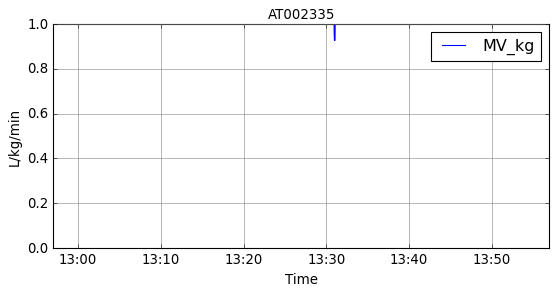

Generated graphs for 22 recordings. 

CPU times: user 1.34 s, sys: 46.5 ms, total: 1.39 s
Wall time: 1.44 s


In [298]:
%%time

par = 'MV_kg'
dim = 'L/kg/min'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if par not in data_pars_measurements_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][par].plot(ax = ax, label = par, x_compat = True)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{par}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

#### E. Ventilator proportion of minute ventilation (during SIMV and SIMVPS only)

In [301]:
%%time

par = 'MVresp'
dim = '%'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if par not in data_pars_measurements_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][par].plot(ax = ax, label = par, x_compat = True)
    ax.set_ylim(0, 105)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{par}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 15 recordings. 

CPU times: user 647 ms, sys: 25.9 ms, total: 672 ms
Wall time: 699 ms


#### F. Pressures (PIP, MAP and PEEP)

In [304]:
%%time

pars = ['PIP', 'MAP', 'PEEP']
name = 'pressures'
dim = 'cmH$_2$O'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if not set(pars).issubset(set(data_pars_measurements_ventilated[case].columns)):
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][pars[0]].plot(x_compat = True)
    data_pars_measurements_ventilated[case][pars[1]].plot(color = 'black', linewidth = 2, x_compat = True)
    data_pars_measurements_ventilated[case][pars[2]].plot(color = 'red', x_compat = True)
    
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend(ncols=3)
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 18 recordings. 

CPU times: user 1.55 s, sys: 54.8 ms, total: 1.6 s
Wall time: 1.67 s


#### G. MAP

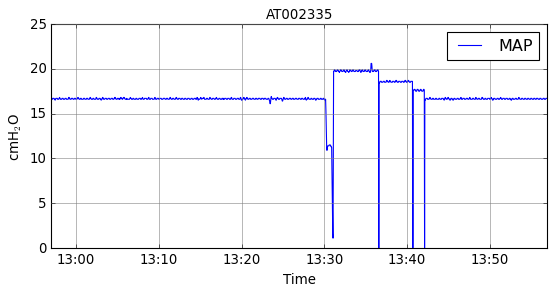

Generated graphs for 22 recordings. 

CPU times: user 1.14 s, sys: 46.7 ms, total: 1.18 s
Wall time: 1.23 s


In [306]:
%%time

pars = ['MAP']
name = 'MAP'
dim = 'cmH$_2$O'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if not set(pars).issubset(set(data_pars_measurements_ventilated[case].columns)):
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][pars[0]].plot(x_compat = True)
    
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

#### H. Backup respiratory rate

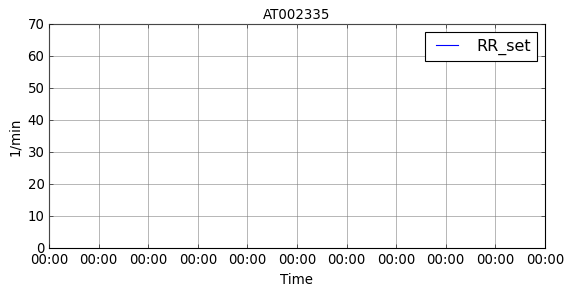

Generated graphs for 19 recordings. 

CPU times: user 1.14 s, sys: 30.3 ms, total: 1.17 s
Wall time: 1.21 s


In [308]:
%%time

par = 'RR_set'
dim = '1/min'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if par not in data_pars_settings_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax = fig.add_subplot(1, 1, 1)
    data_pars_settings_ventilated[case][par].plot(ax = ax, label = par, x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_ylim(0, 70)
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{par}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

#### I. Actual rate and backup rate for those recordings that have SIPPV and/or SIMPSV parts

In [311]:
%%time

pars = ['RR', 'RR_set']
name = 'rates'
dim = '1/min'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if pars[0] not in data_pars_measurements_ventilated[case].columns:
        continue
    if pars[1] not in data_pars_settings_ventilated[case].columns:
        continue
    if vent_modes_ventilated.loc[case]['SIPPV'] > 0 or vent_modes_ventilated.loc[case]['SIMVPSV'] > 0:
        fig = plt.figure()
        fig.set_size_inches(8, 4)
        fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
        
        ax = fig.add_subplot(1, 1, 1)
        data_pars_measurements_ventilated[case][pars[0]].plot(ax = ax, label = pars[0], x_compat = True)
        data_pars_settings_ventilated[case][pars[1]].plot(ax = ax, label = pars[1], x_compat = True)
        ax.set_xlabel('Time', size = 12, color = 'black')
        ax.set_ylabel(dim, size = 12, color = 'black')
        ax.set_title(case,  size = 12, color = 'black')
        ax.legend()
        ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
        
        majorFmt = dates.DateFormatter('%H:%M')  
        ax.xaxis.set_major_formatter(majorFmt)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
        ax.tick_params(which = 'both', labelsize=12)
            
        fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
        n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 15 recordings. 

CPU times: user 770 ms, sys: 20.6 ms, total: 790 ms
Wall time: 817 ms


#### J. FiO2

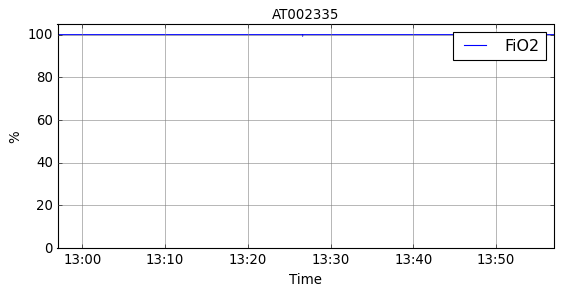

Generated graphs for 22 recordings. 

CPU times: user 1.2 s, sys: 32 ms, total: 1.23 s
Wall time: 1.28 s


In [313]:
%%time

par = 'FiO2'
dim = '%'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:
    
    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][par].plot(ax = ax, label = par, x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_ylim(0, 105)
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{par}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

#### K. Leak

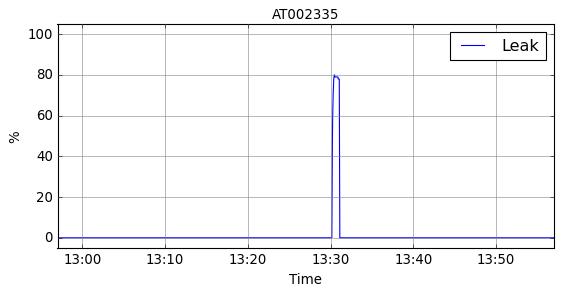

Generated graphs for 22 recordings. 

CPU times: user 1.01 s, sys: 28.8 ms, total: 1.04 s
Wall time: 1.09 s


In [319]:
%%time

par = 'Leak'
dim = '%'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][par].plot(ax = ax, label = par, x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_ylim(-5, 105)
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{par}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

#### L. Flow in the circuit

In [321]:
%%time

pars = ['Flow_insp_set', 'Flow_exp_set']
name = 'Circuit_flow'
dim = 'L/min'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if pars[0] not in data_pars_settings_ventilated[case].columns:
        continue
    if pars[1] not in data_pars_settings_ventilated[case].columns:
        continue     
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax = fig.add_subplot(1, 1, 1)
    data_pars_settings_ventilated[case][pars[0]].plot(ax = ax, label = pars[0], x_compat = True)
    data_pars_settings_ventilated[case][pars[1]].plot(ax = ax, label = pars[1], x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_title(case,  size = 12, color = 'black')
    ax.set_ylim(0,20)
    ax.legend(ncols=2)
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 18 recordings. 

CPU times: user 1.18 s, sys: 30.4 ms, total: 1.21 s
Wall time: 1.28 s


#### M. Triggering sensitivity

In [324]:
%%time

par = 'Trigger_sens_set'
dim = 'L/min'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:
    
    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if par not in data_pars_settings_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax = fig.add_subplot(1, 1, 1)
    data_pars_settings_ventilated[case][par].plot(ax = ax, label = par, x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_ylim(0, 10)
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{par}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 18 recordings. 

CPU times: user 779 ms, sys: 24.2 ms, total: 803 ms
Wall time: 830 ms


#### N. VTemand_kg and VG_set_kg (during VG ventilation)

In [326]:
%%time

pars = ['VTemand_kg', 'VG_set_kg']
name = 'VTemand_VG_set'
dim = 'mL/kg'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if pars[0] not in data_pars_measurements_ventilated[case].columns:
        continue
    if pars[1] not in data_pars_settings_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax0 = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][pars[0]].plot(x_compat = True)
    data_pars_settings_ventilated[case][pars[1]].plot(color = 'red', x_compat = True)
    
    ax0.set_ylim(0, 15)
    ax0.set_xlabel('Time', size = 12, color = 'black')
    ax0.set_ylabel(dim, size = 12, color = 'black')
    ax0.set_title(case,  size = 12, color = 'black')
    ax0.legend(pars, fontsize = 12, ncols=2)
    ax0.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax0.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax0.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax0.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 15 recordings. 

CPU times: user 803 ms, sys: 22.9 ms, total: 826 ms
Wall time: 855 ms


#### O. PIP and Pset /  Pmax

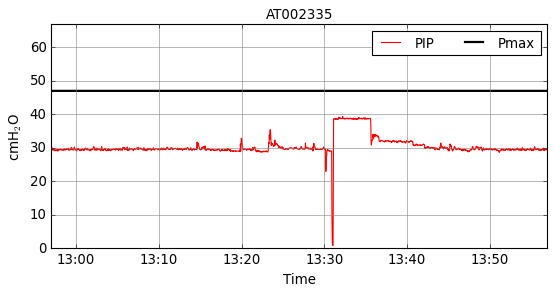

Generated graphs for 22 recordings. 

CPU times: user 1.53 s, sys: 39.7 ms, total: 1.57 s
Wall time: 1.61 s


In [329]:
%%time

pars = ['PIP', 'PIP_set',]
name = 'PIP_Pmax'
dim = 'cmH$_2$O'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if pars[0] not in data_pars_measurements_ventilated[case].columns:
        continue
    if pars[1] not in data_pars_settings_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax0 = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][pars[0]].plot(color = 'red', x_compat = True)
    data_pars_settings_ventilated[case][pars[1]].plot(color = 'black', linewidth = 2, x_compat = True)
    
    ax0.set_ylim(0, data_pars_settings_ventilated[case][pars[1]].max() + 20)
    ax0.set_xlabel('Time', size = 12, color = 'black')
    ax0.set_ylabel(dim, size = 12, color = 'black')
    ax0.set_title(case,  size = 12, color = 'black')
    ax0.legend(['PIP', 'Pmax'], fontsize = 12, ncols=2)
    ax0.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax0.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax0.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax0.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != sorted(data_pars_measurements_ventilated.keys())[-1]:
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

#### P. deltaP and deltaP_set (which is deltaP max during HFOV-VG)

In [331]:
%%time

pars = ['deltaP', 'deltaP_set',]
name = 'deltaP_deltaP_set'
dim = 'cmH$_2$O'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if pars[0] not in data_pars_measurements_ventilated[case].columns:
        continue
    if pars[1] not in data_pars_settings_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax0 = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][pars[0]].plot(color = 'red', x_compat = True)
    data_pars_settings_ventilated[case][pars[1]].plot(color = 'black', linewidth = 2, x_compat = True)
    
    ax0.set_ylim(0, data_pars_settings_ventilated[case][pars[1]].max() + 20)
    ax0.set_xlabel('Time', size = 12, color = 'black')
    ax0.set_ylabel(dim, size = 12, color = 'black')
    ax0.set_title(case,  size = 12, color = 'black')
    ax0.legend(['deltaP', 'deltaP max'], fontsize = 12, ncols=2)
    ax0.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax0.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax0.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax0.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != 'AT001585':
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 8 recordings. 

CPU times: user 452 ms, sys: 14.2 ms, total: 466 ms
Wall time: 483 ms


#### Q. DCO2

In [335]:
%%time

par = 'DCO2_kg2'
dim = r'mL$^2$/s/kg$^2$'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if par not in data_pars_measurements_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][par].plot(color='blue', x_compat=True)
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_ylim(0, 150)
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{par}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != 'AT001585':
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 8 recordings. 

CPU times: user 389 ms, sys: 14.7 ms, total: 403 ms
Wall time: 417 ms


#### R. VTHf

In [337]:
%%time

par = 'VThf_emand_kg'
name = 'VThf'
dim = 'mL/kg'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if par not in data_pars_measurements_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][par].plot(ax = ax, label = 'VThf', x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_ylim(0, 6)
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != 'AT001585':
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 8 recordings. 

CPU times: user 617 ms, sys: 11.3 ms, total: 629 ms
Wall time: 644 ms


#### S. Inspired and expired oscillation volume

In [343]:
%%time

pars = ['VTimand_kg', 'VThf_emand_kg',]
name = 'VThf_imand_emand'
dim = 'mL/kg'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if pars[0] not in data_pars_measurements_ventilated[case].columns:
        continue
    if pars[1] not in data_pars_measurements_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax0 = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][pars[0]].plot(color = 'green', x_compat = True)
    data_pars_measurements_ventilated[case][pars[1]].plot(color = 'blue', linewidth = 2, linestyle='dashed', x_compat = True)
    
    ax0.set_ylim(0, 6)
    ax0.set_xlabel('Time', size = 12, color = 'black')
    ax0.set_ylabel(dim, size = 12, color = 'black')
    ax0.set_title(case,  size = 12, color = 'black')
    ax0.legend(pars, fontsize = 12, ncols=2)
    ax0.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax0.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax0.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax0.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != 'AT001585':
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 8 recordings. 

CPU times: user 465 ms, sys: 17.5 ms, total: 482 ms
Wall time: 500 ms


#### T. VThf and VThf_set (during HFOV-VG)

In [346]:
%%time

pars = ['VThf_emand_kg', 'VG_set_kg',]
name = 'VThf_VTHf_set'
dim = 'mL/kg'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if pars[0] not in data_pars_measurements_ventilated[case].columns:
        continue
    if pars[1] not in data_pars_settings_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax0 = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][pars[0]].plot(color = 'blue', x_compat = True)
    data_pars_settings_ventilated[case][pars[1]].plot(color = 'black', linewidth = 2, linestyle='dashed',
        x_compat = True)
    
    ax0.set_ylim(0, 6)
    ax0.set_xlabel('Time', size = 12, color = 'black')
    ax0.set_ylabel(dim, size = 12, color = 'black')
    ax0.set_title(case,  size = 12, color = 'black')
    ax0.legend(pars, fontsize = 12, ncols=2)
    ax0.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax0.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax0.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax0.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != 'AT001585':
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 6 recordings. 

CPU times: user 334 ms, sys: 12.2 ms, total: 346 ms
Wall time: 356 ms


#### U. Frequency

In [349]:
%%time

pars = ['HFOV_freq', 'Freq_set_HFOV',]
name = 'HFOV_freq_HFOV_freq_set'
dim = 'Hz'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if pars[0] not in data_pars_measurements_ventilated[case].columns:
        continue
    if pars[1] not in data_pars_settings_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax0 = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][pars[0]].plot(color = 'blue', x_compat = True)
    data_pars_settings_ventilated[case][pars[1]].plot(color = 'black', linewidth = 1, linestyle='dashed', 
        x_compat = True)
    
    ax0.set_ylim(0, 18)
    ax0.set_xlabel('Time', size = 12, color = 'black')
    ax0.set_ylabel(dim, size = 12, color = 'black')
    ax0.set_title(case,  size = 12, color = 'black')
    ax0.legend(pars, fontsize = 12)
    ax0.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax0.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax0.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax0.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != 'AT001585':
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 8 recordings. 

CPU times: user 455 ms, sys: 15.9 ms, total: 471 ms
Wall time: 486 ms


#### V. I:E ratio during HFOV

In [352]:
%%time

par = 'I_E_HFOV'; name = 'I_E_ratio'
dim = ''; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if par not in data_pars_settings_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax0 = fig.add_subplot(1, 1, 1)
    
    data_pars_settings_ventilated[case][par].plot(color = 'blue', linewidth = 1, linestyle='dashed', x_compat = True)
    
    ax0.set_ylim(0, 1)
    ax0.set_xlabel('Time', size = 12, color = 'black')
    ax0.set_ylabel(dim, size = 12, color = 'black')
    ax0.set_title(case,  size = 12, color = 'black')
    ax0.legend(pars, fontsize = 12)
    ax0.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax0.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax0.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax0.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{name}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != 'AT001585':
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 22 recordings. 

CPU times: user 1.18 s, sys: 36.5 ms, total: 1.22 s
Wall time: 1.27 s


#### W. etCO2

In [354]:
%%time

par = 'etCO2'
dim = 'mmHg'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if par not in data_pars_measurements_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][par].plot(ax = ax, label = par, x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_ylim(0, 100)
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{par}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != 'AT001580':
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 6 recordings. 

CPU times: user 259 ms, sys: 9.78 ms, total: 269 ms
Wall time: 281 ms


#### X. Respiratory rate determined from capnography data

In [358]:
%%time

par = 'RR_CO2'
dim = '1/min'; filetype = 'jpg'; dpi = 200
n=0

for case in data_pars_measurements_ventilated:

    if int(case[2:].lstrip('0')) <= graphs_from:
        continue
    if par not in data_pars_measurements_ventilated[case].columns:
        continue
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
    
    ax = fig.add_subplot(1, 1, 1)
    data_pars_measurements_ventilated[case][par].plot(ax = ax, label = par, x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel(dim, size = 12, color = 'black')
    ax.set_ylim(0, 150)
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid('on', linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_ventilated_{par}.{filetype}'), 
        dpi = dpi, bbox_inches='tight', pad_inches=0.1,)
    n+=1
    
    if case != 'AT001580':
        plt.close()
    else:
        plt.show()

print(f'Generated graphs for {n} recordings.', '\n')

Generated graphs for 7 recordings. 

CPU times: user 356 ms, sys: 13.8 ms, total: 370 ms
Wall time: 868 ms


### 15. Text files with additional info

In [360]:
['Bias_flow', 'FOT_running', 'Flow_sensor_state', 'HFO_flow', 'HFO_recruitment', 'Leak_comp', 'Measuring_unit_CO2_set', 'Measuring_unit_pressure_set', 'O2_compensation_set', 'Oxy_sensor_state', 'Patient_range', 'Powerstate', 'Pressure_rise_control', 'RR_backup_set', 'RR_lim_set', 'Trigger_mode', 'Trigger_mode_2', 'VG_state', 'Ventilation_stopped', 'Ventilator_mode', 'Ventilator_range']

['Bias_flow',
 'FOT_running',
 'Flow_sensor_state',
 'HFO_flow',
 'HFO_recruitment',
 'Leak_comp',
 'Measuring_unit_CO2_set',
 'Measuring_unit_pressure_set',
 'O2_compensation_set',
 'Oxy_sensor_state',
 'Patient_range',
 'Powerstate',
 'Pressure_rise_control',
 'RR_backup_set',
 'RR_lim_set',
 'Trigger_mode',
 'Trigger_mode_2',
 'VG_state',
 'Ventilation_stopped',
 'Ventilator_mode',
 'Ventilator_range']

In [363]:
%%time

for case in data_pars_settings_ventilated:
    a = data_pars_settings_ventilated[case]
  
    fileout = open(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_vent_info_ventilated.txt'), 'w')
    if 'Patient_range' in a.columns:
        fileout.write('Patient range: %s\n' % a['Patient_range'].unique().tolist())
    if 'Ventilator_mode' in a.columns:
        fileout.write('Ventilator mode: %s\n' % a['Ventilator_mode'].unique().tolist())
    if 'Ventilator_range' in a.columns:
        fileout.write('Ventilator range: %s\n\n' % a['Ventilator_range'].unique().tolist())
    if 'Leak_comp' in a.columns:
        fileout.write('Leak compensation: %s\n' % a['Leak_comp'].unique().tolist())
    if 'Bias_flow' in a.columns:
        fileout.write('Bias flow: %s\n' % a['Bias_flow'].unique().tolist())
    if 'Pressure_rise_control' in a.columns:
        fileout.write('Pressure rise control: %s\n' % a['Pressure_rise_control'].unique().tolist())
    if 'Trigger_mode_2' in a.columns:
        fileout.write('Trigger mode: %s\n' % a['Trigger_mode_2'].unique().tolist())
    
    fileout.close()

CPU times: user 1.41 s, sys: 643 ms, total: 2.06 s
Wall time: 3.69 s
